# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max.columns",None)

----

### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

The data file given is not a csv file or a excel file it is parquet file

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [3]:
df = pd.read_parquet("/Users/aryankakkar/Desktop/DA/Projects/NYC/EDA_NYC_Sample_Data/NYC_Taxi_Sample_5pct.parquet")
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,1,2023-01-05 07:50:08,2023-01-05 08:02:04,2.0,1.90,1.0,N,239,236,1,13.5,2.5,0.5,2.50,0.0,1.0,20.00,2.5,0.0,NaN
1,2,2023-01-17 07:47:24,2023-01-17 08:00:50,5.0,1.86,1.0,N,239,162,1,14.2,0.0,0.5,3.64,0.0,1.0,21.84,2.5,0.0,NaN
2,2,2023-01-25 21:57:59,2023-01-25 22:00:33,1.0,0.50,1.0,N,162,170,1,5.1,1.0,0.5,2.02,0.0,1.0,12.12,2.5,0.0,NaN
3,2,2023-01-09 19:36:54,2023-01-09 19:52:01,2.0,2.56,1.0,N,162,262,1,17.0,2.5,0.5,4.70,0.0,1.0,28.20,2.5,0.0,NaN
4,1,2023-01-11 22:19:13,2023-01-11 22:32:37,1.0,2.80,1.0,N,164,231,1,14.9,3.5,0.5,3.98,0.0,1.0,23.88,2.5,0.0,NaN


---

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Check for Basic Information of the data.

In [4]:
print("Total No. of Rows=> ",df.shape[0])
print("Total No. of Columns=> ",df.shape[1])

Total No. of Rows=>  1896427
Total No. of Columns=>  20


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1896427 entries, 0 to 1896426
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64   

In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,1896427.0,1.736307,1.0,1.0,2.0,2.0,6.0,0.446046
tpep_pickup_datetime,1896427,2023-07-02 20:03:31.073996,2001-01-01 00:06:49,2023-04-02 16:24:36,2023-06-27 15:13:55,2023-10-06 19:56:07,2023-12-31 23:58:14,NaN
tpep_dropoff_datetime,1896427,2023-07-02 20:21:03.739193,2001-01-01 15:42:11,2023-04-02 16:46:50,2023-06-27 15:32:30,2023-10-06 20:14:15.500000,2024-01-01 23:02:22,NaN
passenger_count,1831503.0,1.369667,0.0,1.0,1.0,1.0,9.0,0.893926
trip_distance,1896427.0,4.163961,0.0,1.05,1.79,3.4,186514.09,253.789372
RatecodeID,1831503.0,1.650204,1.0,1.0,1.0,1.0,99.0,7.486294
PULocationID,1896427.0,165.219977,1.0,132.0,162.0,234.0,265.0,64.002095
DOLocationID,1896427.0,163.994606,1.0,113.0,162.0,234.0,265.0,69.891818
payment_type,1896427.0,1.163072,0.0,1.0,1.0,1.0,4.0,0.507818
fare_amount,1896427.0,19.897127,0.0,9.3,13.5,22.29,2194.7,18.501055


In [7]:
missing_val = pd.DataFrame()
missing_val["missing_val"] = df.isnull().sum()
missing_val["missing_val(%)"] = (((missing_val/df.shape[0])*100).round(2)).astype(str) + "%"
missing_val = missing_val[missing_val["missing_val"] > 0]

missing_val

,missing_val,missing_val(%)
passenger_count,64924,3.42%
RatecodeID,64924,3.42%
store_and_fwd_flag,64924,3.42%
congestion_surcharge,64924,3.42%
airport_fee,1747907,92.17%
Airport_fee,213444,11.26%


In [8]:
df.duplicated().sum()

np.int64(0)

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

## Dropping coloumn that were not used in our analysis.
- Airport fee columns that were 2 different columns have already been deleted and in place a that a new Airport_Fee column was made.
- store_and_fwd_flag column was not used at any place lets remove that at very last of section 3

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

### To Combine this we can use + operator and this will add both the columns
- There are some NaN values in the columns so if we + any value with Null value it will give Nan only.
- Here we have to fix null values first
- We assume that in Airport fee if there is null value that means There is no Airport fee for the charged in that particular record.
- We will fill null values to 0 in both the columns.
- Thereafter we will use + operator and add both the columns and will create the new column.
  #### ***Here we have created a New Column "Airport_Fee"***

In [9]:
df.airport_fee = df.airport_fee.fillna(0)
df.Airport_fee = df.Airport_fee.fillna(0)

In [10]:
df["Airport_Fee"] = df.airport_fee+df.Airport_fee
df[df.Airport_Fee>0]["Airport_Fee"].head()

12    1.25
20    1.25
29    1.25
34    1.25
43    1.25
Name: Airport_Fee, dtype: float64

In [11]:
df.drop(columns=["airport_fee", "Airport_fee"], inplace=True)

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [12]:
# check where values of fare amount are negative

### There is no negative value in the Fare amount column but there are negative records in other columns

Did you notice something different in the `RatecodeID` column for above records?

In [13]:
# Analyse RatecodeID for the negative fare amounts

df[(df.total_amount<0) | (df.mta_tax<0) | (df.extra<0) | (df.improvement_surcharge<0) | (df.congestion_surcharge<0) | (df.Airport_Fee<0) | (df.tolls_amount<0)]["RatecodeID"].value_counts()

# Most of the RatecodeIDs were 1 & 2 where there are negative values. 

RatecodeID
1.0    67
2.0    33
3.0     4
5.0     2
4.0     1
Name: count, dtype: int64

In [14]:
df.RatecodeID.value_counts()

RatecodeID
1.0     1727911
2.0       72246
99.0      10737
5.0       10724
3.0        6173
4.0        3712
Name: count, dtype: int64

In [15]:
# Also Rate code id includes 99 Which is Null/unknown in the data dictionary we will look after this at later stages.

In [16]:
# Find which columns have negative values

- From df.describe() we saw the min value of value columns.
- negative appears in [total_amount,mta_tax,extra,improvement_surcharge,congestion_surcharge,Airport_Fee,tolls_amount]

In [17]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,1896427.0,1.736307,1.0,1.0,2.0,2.0,6.0,0.446046
tpep_pickup_datetime,1896427,2023-07-02 20:03:31.073996,2001-01-01 00:06:49,2023-04-02 16:24:36,2023-06-27 15:13:55,2023-10-06 19:56:07,2023-12-31 23:58:14,NaN
tpep_dropoff_datetime,1896427,2023-07-02 20:21:03.739193,2001-01-01 15:42:11,2023-04-02 16:46:50,2023-06-27 15:32:30,2023-10-06 20:14:15.500000,2024-01-01 23:02:22,NaN
passenger_count,1831503.0,1.369667,0.0,1.0,1.0,1.0,9.0,0.893926
trip_distance,1896427.0,4.163961,0.0,1.05,1.79,3.4,186514.09,253.789372
RatecodeID,1831503.0,1.650204,1.0,1.0,1.0,1.0,99.0,7.486294
PULocationID,1896427.0,165.219977,1.0,132.0,162.0,234.0,265.0,64.002095
DOLocationID,1896427.0,163.994606,1.0,113.0,162.0,234.0,265.0,69.891818
payment_type,1896427.0,1.163072,0.0,1.0,1.0,1.0,4.0,0.507818
fare_amount,1896427.0,19.897127,0.0,9.3,13.5,22.29,2194.7,18.501055


In [18]:
# fix these negative values



In [19]:
df[(df.total_amount<0) | (df.mta_tax<0) | (df.extra<0) | (df.improvement_surcharge<0) | (df.congestion_surcharge<0) | (df.Airport_Fee<0) | (df.tolls_amount<0)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee
6585,2,2023-01-13 06:19:23,2023-01-13 06:19:27,1.0,0.00,1.0,N,132,132,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-2.75,0.0,-1.25
9570,2,2023-01-14 12:03:42,2023-01-14 12:03:49,2.0,0.00,2.0,N,13,13,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
38700,2,2023-01-24 10:09:06,2023-01-24 10:59:05,1.0,18.89,2.0,N,48,132,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
41140,2,2023-01-21 11:43:46,2023-01-21 11:44:14,1.0,0.06,2.0,N,164,164,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
50597,2,2023-01-26 12:03:41,2023-01-26 12:27:23,1.0,3.62,1.0,N,186,231,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1654807,2,2023-07-27 14:12:45,2023-07-27 14:13:06,1.0,0.00,2.0,N,162,162,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
1671620,2,2023-07-21 14:49:29,2023-07-21 15:25:04,1.0,3.33,1.0,N,43,234,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
1721590,2,2023-07-10 12:24:33,2023-07-10 12:25:49,1.0,0.00,1.0,N,207,207,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-1.50,0.0,0.00
1854518,2,2023-09-19 12:10:37,2023-09-19 12:36:54,1.0,15.99,1.0,N,132,226,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-3.25,0.0,-1.75


### Since these were only 107 rows and almost all the values of fair amount was 0 except 1 
- #### so its better to drop off there
- The one row where the fair was not 0 was valid but there was a negative value in extra column so as no such info about negative is given
- Its fine if we drop 107 rows out of 1.9 million rows.

In [20]:
negative_records = df[(df.total_amount<0) | (df.mta_tax<0) | (df.extra<0) | (df.improvement_surcharge<0) | (df.congestion_surcharge<0) | (df.Airport_Fee<0) | (df.tolls_amount<0)]

In [21]:
df.drop(negative_records.index,inplace=True)

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [22]:
missing_val = pd.DataFrame()
missing_val["missing_val"] = df.isnull().sum()
missing_val["missing_val(%)"] = (((missing_val/df.shape[0])*100).round(2)).astype(str) + "%"
missing_val = missing_val[missing_val["missing_val"] > 0]

missing_val

,missing_val,missing_val(%)
passenger_count,64924,3.42%
RatecodeID,64924,3.42%
store_and_fwd_flag,64924,3.42%
congestion_surcharge,64924,3.42%


In [23]:
# Now we dont have Airport fee column here in null values if we compare the result with Data Understanding portion Solution
# Because we fill nun values with 0.

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

### There are **64924 Null values** & **29254 "0" value** in Passenger_count column 

In [24]:
df.passenger_count.value_counts(dropna=False)

passenger_count
1.0    1377958
2.0     276862
3.0      68729
NaN      64924
4.0      38553
0.0      29254
5.0      23957
6.0      16068
8.0         12
7.0          2
9.0          1
Name: count, dtype: int64

In [25]:
df[df.passenger_count.isnull()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee
155,2,2023-01-20 15:15:17,2023-01-20 15:27:06,NaN,1.35,NaN,NaN,142,239,0,13.65,0.0,0.5,3.53,0.0,1.0,21.18,NaN,0.0
157,2,2023-01-21 15:17:59,2023-01-21 15:39:36,NaN,6.67,NaN,NaN,170,41,0,27.71,0.0,0.5,7.34,0.0,1.0,39.05,NaN,0.0
303,2,2023-01-28 23:58:47,2023-01-29 00:11:44,NaN,1.73,NaN,NaN,211,4,0,15.55,0.0,0.5,3.91,0.0,1.0,23.46,NaN,0.0
309,1,2023-01-21 02:51:57,2023-01-21 03:15:22,NaN,0.00,NaN,NaN,79,166,0,22.83,0.0,0.5,0.00,0.0,1.0,26.83,NaN,0.0
356,2,2023-01-17 21:22:28,2023-01-17 21:36:25,NaN,2.43,NaN,NaN,143,263,0,15.21,0.0,0.5,2.88,0.0,1.0,22.09,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896278,1,2023-09-20 07:46:28,2023-09-20 07:52:42,NaN,0.00,NaN,NaN,239,238,0,13.88,0.0,0.5,0.00,0.0,1.0,17.88,NaN,0.0
1896336,1,2023-09-26 15:25:35,2023-09-26 15:28:20,NaN,0.60,NaN,NaN,13,13,0,5.80,0.0,0.5,2.45,0.0,1.0,12.25,NaN,0.0
1896347,2,2023-09-06 12:42:00,2023-09-06 13:22:00,NaN,3.44,NaN,NaN,164,239,0,22.20,0.0,0.5,0.00,0.0,1.0,26.20,NaN,0.0
1896381,2,2023-09-16 12:58:00,2023-09-16 13:26:00,NaN,7.32,NaN,NaN,13,80,0,35.25,0.0,0.5,0.00,0.0,1.0,39.25,NaN,0.0


### In order to fill Null values the best way is to use mode/median of the data
- #### As we don't know what actually the data is.
- We can see here the mode and median value both are 1 so we are going to fill 1.

In [26]:
df.passenger_count.median()

1.0

In [27]:
df.passenger_count.mode()

0    1.0
Name: passenger_count, dtype: float64

In [28]:
df.passenger_count = df.passenger_count.fillna(df.passenger_count.mode()[0])

Did you find zeroes in passenger_count? Handle these.

### Yes there are **29254** "0" Values present in the data.

In [29]:
df[df.passenger_count==0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee
76,1,2023-01-06 08:47:54,2023-01-06 08:52:10,0.0,0.6,1.0,N,236,263,1,6.5,2.5,0.5,2.60,0.0,1.0,13.10,2.5,0.0
106,1,2023-01-13 20:20:34,2023-01-13 20:32:57,0.0,1.4,1.0,N,249,107,1,10.7,3.5,0.5,2.36,0.0,1.0,18.06,2.5,0.0
198,1,2023-01-14 23:41:06,2023-01-14 23:57:20,0.0,1.8,1.0,N,90,79,1,15.6,3.5,0.5,4.10,0.0,1.0,24.70,2.5,0.0
210,1,2023-01-17 06:34:05,2023-01-17 06:43:42,0.0,1.3,1.0,N,170,233,2,8.6,2.5,0.5,0.00,0.0,1.0,12.60,2.5,0.0
235,1,2023-01-19 08:24:59,2023-01-19 08:52:12,0.0,3.8,1.0,N,142,113,1,25.4,2.5,0.5,7.30,0.0,1.0,36.70,2.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896202,1,2023-09-02 19:59:22,2023-09-02 20:06:55,0.0,1.5,1.0,N,237,142,1,10.0,3.5,0.5,2.25,0.0,1.0,17.25,2.5,0.0
1896271,1,2023-09-27 18:44:57,2023-09-27 19:16:50,0.0,5.8,1.0,N,90,24,1,31.0,5.0,0.5,0.00,0.0,1.0,37.50,2.5,0.0
1896378,1,2023-09-12 14:58:52,2023-09-12 15:16:10,0.0,3.6,1.0,N,229,232,1,20.5,2.5,0.5,3.00,0.0,1.0,27.50,2.5,0.0
1896401,1,2023-09-27 20:56:00,2023-09-27 21:02:53,0.0,2.6,1.0,N,209,4,1,12.1,5.0,0.5,3.70,0.0,1.0,22.30,2.5,0.0


### Here also as we do not have any data we are going to fill median/mode over these vals.

In [30]:
passenger_0 = df[df.passenger_count==0]

In [31]:
df.loc[passenger_0.index,"passenger_count"] = df.passenger_count.mode()[0]

In [32]:
df.passenger_count.isnull().sum()   #0 null values 

np.int64(0)

In [33]:
df[df.passenger_count==0].shape[0] #0 records where the passenger count is 0.

0

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [34]:
# Fix missing values in 'RatecodeID'


In [35]:
df.RatecodeID.value_counts()

RatecodeID
1.0     1727844
2.0       72213
99.0      10737
5.0       10722
3.0        6169
4.0        3711
Name: count, dtype: int64

In [36]:
df.RatecodeID.isnull().sum()

np.int64(64924)

### We can see here we have 99 as Ratecode ID
- ### when checked Data dictionary is it is mentioned there that the 99 Ratecode ID is for those Unknown Null values.
- So we are going to fill the null values with 99 as this ID is specially made for Unknown values.

In [37]:
df.RatecodeID = df.RatecodeID.fillna(99)

In [38]:
df.RatecodeID.isnull().sum() # 0 Null Values.

np.int64(0)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [39]:
# handle null values in congestion_surcharge




In [40]:
df.congestion_surcharge.isnull().sum()

np.int64(64924)

In [41]:
df.congestion_surcharge.value_counts(dropna=False)

congestion_surcharge
2.5    1691632
0.0     139763
NaN      64924
1.0          1
Name: count, dtype: int64

### As we do not have any information about the Null values we are going to use median/mode 
- We can see here the mode and median value both are 2.5 so we are going to fill 2.5.

In [42]:
df.congestion_surcharge.median()

2.5

In [43]:
df.congestion_surcharge.mode()

0    2.5
Name: congestion_surcharge, dtype: float64

In [44]:
df.congestion_surcharge.isnull().sum()

np.int64(64924)

In [45]:
df.congestion_surcharge = df.congestion_surcharge.fillna(df.congestion_surcharge.mode()[0])

In [46]:
df.congestion_surcharge.isnull().sum() #0 null values.

np.int64(0)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [47]:
# Handle any remaining missing values



In [48]:
df.isnull().sum()

VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count              0
trip_distance                0
RatecodeID                   0
store_and_fwd_flag       64924
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge         0
Airport_Fee                  0
dtype: int64

### Yes we can see that in column store_and_fwd_flag there are **64924 Null Values**

In [49]:
df.store_and_fwd_flag.value_counts(dropna=False)

store_and_fwd_flag
N      1820325
NaN      64924
Y        11071
Name: count, dtype: int64

### Again As we do not have any other information we have to fill null values with mode as it is a tectual column.
- We can see here the mode value is "N" so we are going to fill "N".

In [50]:
df.store_and_fwd_flag.mode()

0    N
Name: store_and_fwd_flag, dtype: str

In [51]:
df.store_and_fwd_flag = df.store_and_fwd_flag.fillna(df.store_and_fwd_flag.mode()[0])

In [52]:
df.store_and_fwd_flag.isnull().sum() #) Null Values

np.int64(0)

## Below we Can see that there is No null values left in any column so null value fixed.

In [53]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_Fee              0
dtype: int64

In [54]:
df.isnull().sum().sum() #0 Null Values

np.int64(0)

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

# Note: negative values are already handelled above so in the below record negative will not be present.

Before we start fixing outliers, let's perform outlier analysis.

In [55]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns



In [56]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,1896320.0,1.736292,1.0,1.0,2.0,2.0,6.0,0.446055
tpep_pickup_datetime,1896320,2023-07-02 20:05:06.786494,2001-01-01 00:06:49,2023-04-02 16:25:13,2023-06-27 15:15:56.500000,2023-10-06 19:56:22,2023-12-31 23:58:14,NaN
tpep_dropoff_datetime,1896320,2023-07-02 20:22:39.418041,2001-01-01 15:42:11,2023-04-02 16:47:04.750000,2023-06-27 15:35:17.500000,2023-10-06 20:14:35.750000,2024-01-01 23:02:22,NaN
passenger_count,1896320.0,1.372432,1.0,1.0,1.0,1.0,9.0,0.865788
trip_distance,1896320.0,4.16399,0.0,1.05,1.79,3.4,186514.09,253.796527
RatecodeID,1896320.0,4.983162,1.0,1.0,1.0,1.0,99.0,19.169831
PULocationID,1896320.0,165.220564,1.0,132.0,162.0,234.0,265.0,64.001737
DOLocationID,1896320.0,163.994612,1.0,113.0,162.0,234.0,265.0,69.89159
payment_type,1896320.0,1.163024,0.0,1.0,1.0,1.0,4.0,0.507792
fare_amount,1896320.0,19.898248,0.0,9.3,13.5,22.31,2194.7,18.500975


### From df.describe We can check the min,max,25%,75% to check our outliers.
- ***Vendor Id*** => max val is 6 because we have a vendor whose id is 6 so it is not an outlier.
  - Although its not mentioned in this notebook data dictionary but we have 6 id in original data dictionary which is 6 = Myle Technologies Inc
---
- ***passenger_count*** => all min,max,25%,75% have 1 because we saw that there are most of the records where it was 1 but having a max_val 9 in this column can be an outlier.
---
- ***trip_distance*** => 25% and 75% val is 1.05 & 3.4 resp (We can see here the ouliers are present both in min and max val.
  - trip distance can't be 0 but if for any reason the Taxi was cancelled then it can be possible. It is not sure whether its justified or not. So it will be treated as outlier for now.
  - Also we can se the max value its 186514.09 thats for sure an outlier value.
---
- ***RatecodeID*** => This Contains 99 as max But we know from data dictionary that 99 Ratecode Id is given to Unknown Records. So its not an oulier
---
- ***payment_type*** => The minimum value is 0. Initially, this looked unusual because 0 was not defined in the older data dictionary used in the notebook. After checking the current NYC TLC data dictionary, 0 represents a Flex Fare trip. Therefore, payment_type = 0 is a valid category and should not be treated as an outlier by itself.
---
- ***fare_amount*** => Most of the values were between 9.3 and 22.31 but if we look at both min and max values we can see:
  - Min is 0 that means there are some records where the fare amount was 0 but it is generally not valid we will find this out ahead.
  - Max value is 2194.7 this can be an outlier we will look after this.
---
- ***mta_tax*** => This is to be 0.5 as per data dictionary but if we look at max val it is 4. This needs to be checked.
---
- ***tip_amount*** => Look at the max value which is 300.0 here this is now an outlier.
---
- ***tolls_amount*** => Looking at the min,25%,75% we can see it was mostly zero but in max it is 132.04 so this is an outlier.
---
- ***total_amount*** => Look at the min and max values which is 0.0 and 2203.14 this must be looked after these are outliers (Total amounts can never be 0).
---

# We will see each column we found out above and deeply analyze and fix the outliers or invalid values.

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [57]:
# remove passenger_count > 6


## 1. passenger_count
### First for the Passenger count we are going to drop records where the passenger count was more than 6.
- Through value counts and filteration we can see that there are only 15 records where the passenger count was more than 6.
- Dropping this wont have a major impact on our data analysis.

In [58]:
df.passenger_count.value_counts()

passenger_count
1.0    1472136
2.0     276862
3.0      68729
4.0      38553
5.0      23957
6.0      16068
8.0         12
7.0          2
9.0          1
Name: count, dtype: int64

In [59]:
df.drop(df[df.passenger_count>6].index,inplace=True)

In [60]:
df[df.passenger_count>6].shape[0] #All records were dropped where the passenger count was more than 6.

0

In [61]:
df["Minutes_Taken"] = ((df.tpep_dropoff_datetime - df.tpep_pickup_datetime).dt.total_seconds() / 60).round(1)

In [62]:
df["Minutes_Duration"] = df.Minutes_Taken.apply(lambda x: "0-Minutes" if x == 0 else "(0-5)Minutes" if 0<x<=5 else "(5-30)Minutes" if 5<x<=30 else "Over-30-Minutes")

In [63]:
df.Minutes_Duration.value_counts()

Minutes_Duration
(5-30)Minutes      1454407
Over-30-Minutes     226748
(0-5)Minutes        213557
0-Minutes             1593
Name: count, dtype: int64

In [64]:
df[df.Minutes_Taken<0].shape[0]

109

### There are 109 Values where the Drop off time is earlier than the pickup time so Its not valid this can be dropped.

In [65]:
df.drop(df[df.Minutes_Taken<0].index,inplace=True)

In [66]:
# Q1 = df.Minutes_Taken.quantile(0.25)
# Q3 = df.Minutes_Taken.quantile(0.75)
# IQR = Q3 - Q1

# lower_fence = Q1 - 1.5 * IQR
# upper_fence = Q3 + 1.5 * IQR

# print(f"Q1 (25th pct) : {Q1:,.0f}")
# print(f"Q3 (75th pct) : {Q3:,.0f}")
# print(f"IQR           : {IQR:,.0f}")
# print(f"Lower fence   : {lower_fence:,.0f}")
# print(f"Upper fence   : {upper_fence:,.0f}")

## 2. trip_distance
- Trip distance was 0 in 36818 records now thats sounds unrealistic lets find out why these where 0.
- We found out that when the PULocationID and DOLocationID was same and the distance was 0 and the fare amount was also 0 these were 196 records
  - Now these 196 records are of no use because the condition says that these may got cancelled so its better to drop these for evaluation.
- We also checked records where trip distance was 0, ids were same but fare amount was charged So these maybe real records its just the data is not present. Its not right to directly drop them. These were 15077 records
- 

In [67]:
df[df.trip_distance==0].shape[0]

36818

In [68]:
df[(df.trip_distance==0) & (df.PULocationID==df.DOLocationID) & (df.fare_amount==0)].shape[0]

196

In [69]:
df.drop(df[(df.trip_distance==0) & (df.PULocationID==df.DOLocationID) & (df.fare_amount==0)].index,inplace=True)

In [70]:
df[(df.trip_distance==0) & (df.PULocationID==df.DOLocationID)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
34,2,2023-01-17 19:11:37,2023-01-17 19:11:53,1.0,0.0,2.0,N,114,114,1,70.00,5.00,0.5,25.66,6.55,1.0,112.46,2.5,1.25,0.3,(0-5)Minutes
236,2,2023-01-08 20:38:28,2023-01-08 20:39:11,1.0,0.0,5.0,N,74,74,1,22.00,0.00,0.0,5.75,0.00,1.0,28.75,0.0,0.00,0.7,(0-5)Minutes
376,2,2023-01-30 15:04:15,2023-01-30 15:04:18,1.0,0.0,2.0,N,107,107,2,70.00,0.00,0.5,0.00,0.00,1.0,74.00,2.5,0.00,0.0,0-Minutes
515,1,2023-01-12 20:03:14,2023-01-12 20:03:21,1.0,0.0,1.0,Y,132,132,2,3.00,2.25,0.5,0.00,0.00,1.0,6.75,0.0,1.25,0.1,(0-5)Minutes
768,1,2023-01-23 03:28:34,2023-01-23 03:28:50,1.0,0.0,5.0,N,50,50,1,29.99,0.00,0.0,0.00,0.00,1.0,30.99,0.0,0.00,0.3,(0-5)Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896024,2,2023-09-11 00:20:46,2023-09-11 00:21:11,1.0,0.0,5.0,N,148,148,1,18.00,0.00,0.0,5.38,0.00,1.0,26.88,2.5,0.00,0.4,(0-5)Minutes
1896071,2,2023-09-02 12:18:26,2023-09-02 12:18:52,1.0,0.0,5.0,N,230,230,1,10.00,0.00,0.0,0.00,0.00,1.0,13.50,2.5,0.00,0.4,(0-5)Minutes
1896077,2,2023-09-21 08:01:39,2023-09-21 08:01:57,1.0,0.0,1.0,N,75,75,2,3.00,0.00,0.5,0.00,0.00,1.0,4.50,0.0,0.00,0.3,(0-5)Minutes
1896340,2,2023-09-06 19:42:10,2023-09-06 19:42:35,1.0,0.0,5.0,N,90,90,1,9.00,0.00,0.5,3.10,2.50,1.0,18.60,2.5,0.00,0.4,(0-5)Minutes


### Out of total 36818 records 15077 records were those where the trip distance was 0 but the ids are same.
### And We checked that there were 21545 records where the Ids were different but the distance was 0
- Out of these 21545 rows there were 41 records where Minutes and Fare Amount was also 0.
- these 41 rows have zero distance, zero duration, and zero fare — nothing measurable happened. So it should be dropped.
- Now there were some values where the Distance and minutes were 0, Location ids are diff also the fare is more than 0. These were 766 records. Now if the trip distance and miniutes taken are 0 but the fare was charged also the ids were different this may interpret that the meter was not properly engaged/disengaged.

In [71]:
df[(df.trip_distance==0) & (df.PULocationID!=df.DOLocationID)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
47,2,2023-01-21 21:41:23,2023-01-21 21:52:34,2.0,0.0,1.0,N,236,162,1,10.70,1.0,0.5,3.14,0.0,1.0,18.84,2.5,0.0,11.2,(5-30)Minutes
92,1,2023-01-29 09:09:17,2023-01-29 09:27:10,1.0,0.0,1.0,N,147,241,1,27.50,0.0,0.5,0.00,0.0,1.0,29.00,0.0,0.0,17.9,(5-30)Minutes
156,2,2023-01-14 03:12:35,2023-01-14 03:12:46,1.0,0.0,5.0,N,233,170,4,25.00,0.0,0.0,0.00,0.0,1.0,28.50,2.5,0.0,0.2,(0-5)Minutes
271,2,2023-01-05 09:48:33,2023-01-05 10:07:59,1.0,0.0,1.0,N,239,229,1,16.30,0.0,0.5,3.25,0.0,1.0,23.55,2.5,0.0,19.4,(5-30)Minutes
309,1,2023-01-21 02:51:57,2023-01-21 03:15:22,1.0,0.0,99.0,N,79,166,0,22.83,0.0,0.5,0.00,0.0,1.0,26.83,2.5,0.0,23.4,(5-30)Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896039,1,2023-09-07 12:28:16,2023-09-07 13:28:25,1.0,0.0,99.0,N,13,161,0,39.99,0.0,0.5,0.00,0.0,1.0,43.99,2.5,0.0,60.2,Over-30-Minutes
1896060,2,2023-09-28 12:12:23,2023-09-28 12:36:58,2.0,0.0,1.0,N,43,161,1,19.80,0.0,0.5,3.57,0.0,1.0,27.37,2.5,0.0,24.6,(5-30)Minutes
1896146,1,2023-09-30 12:20:09,2023-09-30 12:23:57,1.0,0.0,1.0,N,140,141,2,4.40,2.5,0.5,0.00,0.0,1.0,8.40,2.5,0.0,3.8,(0-5)Minutes
1896186,1,2023-09-09 10:39:40,2023-09-09 10:39:40,1.0,0.0,1.0,N,249,264,2,3.00,2.5,0.5,0.00,0.0,1.0,7.00,2.5,0.0,0.0,0-Minutes


In [72]:
df[(df.trip_distance==0) & (df.PULocationID!=df.DOLocationID) & (df.Minutes_Taken==0) & (df.fare_amount==0)].shape[0]

41

In [73]:
df.drop(df[(df.trip_distance==0) & (df.PULocationID!=df.DOLocationID) & (df.Minutes_Taken==0) & (df.fare_amount==0)].index,inplace=True)

In [74]:
df[(df.trip_distance==0) & (df.PULocationID!=df.DOLocationID) & (df.Minutes_Taken==0) & (df.fare_amount>0)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
721,1,2023-01-11 20:05:34,2023-01-11 20:05:34,1.0,0.0,1.0,Y,74,264,2,7.9,3.5,0.5,0.0,0.0,1.0,12.9,0.0,0.0,0.0,0-Minutes
1080,1,2023-01-19 21:41:26,2023-01-19 21:41:26,1.0,0.0,1.0,N,161,264,2,14.2,3.5,0.5,0.0,0.0,1.0,19.2,2.5,0.0,0.0,0-Minutes
1270,2,2023-01-04 11:16:41,2023-01-04 11:16:43,1.0,0.0,5.0,N,144,264,1,15.0,0.0,0.0,1.0,0.0,1.0,17.0,0.0,0.0,0.0,0-Minutes
5089,1,2023-01-30 11:55:18,2023-01-30 11:55:18,1.0,0.0,1.0,N,237,264,2,5.1,2.5,0.5,0.0,0.0,1.0,9.1,2.5,0.0,0.0,0-Minutes
13591,1,2023-01-07 18:30:39,2023-01-07 18:30:39,1.0,0.0,1.0,N,231,264,2,3.0,2.5,0.5,0.0,0.0,1.0,7.0,2.5,0.0,0.0,0-Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1889192,1,2023-09-14 19:09:08,2023-09-14 19:09:08,1.0,0.0,1.0,N,233,264,2,7.9,5.0,0.5,0.0,0.0,1.0,14.4,2.5,0.0,0.0,0-Minutes
1889366,1,2023-09-09 13:32:39,2023-09-09 13:32:39,4.0,0.0,1.0,Y,164,264,2,12.8,2.5,0.5,0.0,0.0,1.0,16.8,2.5,0.0,0.0,0-Minutes
1893781,1,2023-09-29 23:18:24,2023-09-29 23:18:24,1.0,0.0,1.0,Y,113,264,2,3.7,3.5,0.5,0.0,0.0,1.0,8.7,2.5,0.0,0.0,0-Minutes
1895562,1,2023-09-15 13:16:42,2023-09-15 13:16:42,1.0,0.0,1.0,N,162,264,2,12.1,2.5,0.5,0.0,0.0,1.0,16.1,2.5,0.0,0.0,0-Minutes


# Handelling 36818 records with a single loop
### Now there are some records where ids are different/same but the distance is 0 and also some records where the distance is not 0 for the same pair of ids.
- For eg If we look below the Ids 263 and 162 at the first record.
- We are going to found out the records exact same pairs were 263 and 162 where the trip distance was not 0 and from those records we are going to find median of trip distance from those records and fill that median on the records where the trip distance was 0.
- There are so many pairs of this just like 263 and 162 so we will write a loop for this.

## Loop to fill values to the pair ids where the distance was 0
- Median will be fetch from the particalar pair id trip distance where trip distance was more than 0.
- Below i and j are the pairs we have filtered it.
- At each i only the unique values of Pickup location id will come where the distance is 0.
- At each j Drop of location if will come that pairs to the above i.

### We have handelled 36818 records where the Ids were different but the trip distance was 0 Using the for loop
- Now by running the loop. There happens to come some null values in the trip_distance. These were 1172 records.
- This null value comes on those records where the pair ids were only one in the entire data set or not having any record where the trip distance was present
- Loop found all pairs but as the trip distance was 0 only in the entire data for the ids The median gave Null values.
- As we dont have any info about the value where null appears we simply drop these records where null comes.

In [75]:
for i in df[df["trip_distance"]==0]["PULocationID"].unique():
    for j in df[(df["trip_distance"]==0) & (df["PULocationID"]==i)]["DOLocationID"]:
            median = df[(df.PULocationID==i) & (df.DOLocationID==j) & (df.trip_distance>0)]["trip_distance"].median()
            index = df[(df.trip_distance==0) & (df.PULocationID==i) & (df.DOLocationID==j)]["trip_distance"].index
            df.loc[index,"trip_distance"] = median

In [76]:
df[(df.trip_distance==0)].shape[0]

0

In [77]:
df.trip_distance.isnull().sum()

np.int64(1172)

In [78]:
df.drop(df[(df.trip_distance.isnull())].index,inplace=True)

In [79]:
df.trip_distance.isnull().sum()

np.int64(0)

---

### Handling extreme trip distances
- The trip_distance column has some very large values. The maximum distance is 186,514.09, while 75% of the trips are 3.4 or less.
- A trip above 250 miles is very unusual for the given records. These values may be incorrect and can affect our analysis.
- So, we treated trips above 250 miles as outliers and removed them. They were 42.

In [80]:
df.trip_distance.max()

186514.09

In [81]:
df.trip_distance.describe()

count    1.894787e+06
mean     4.210699e+00
std      2.538990e+02
min      1.000000e-02
25%      1.090000e+00
50%      1.800000e+00
75%      3.460000e+00
max      1.865141e+05
Name: trip_distance, dtype: float64

In [82]:
df[df.trip_distance > 250].shape[0]

42

In [83]:
df.drop(df[df.trip_distance > 250].index,inplace=True)

In [84]:
df.trip_distance.max()

227.34

In [85]:
df[(df.trip_distance>50) & (df.trip_distance<100)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
3258,2,2023-01-22 22:01:09,2023-01-22 23:31:09,1.0,60.69,5.0,N,132,265,1,275.00,0.0,0.0,90.30,25.00,1.0,392.55,0.0,1.25,90.0,Over-30-Minutes
12761,2,2023-01-27 15:22:14,2023-01-27 17:05:33,1.0,54.95,3.0,N,132,265,1,219.00,0.0,0.0,11.00,19.30,1.0,250.30,0.0,0.00,103.3,Over-30-Minutes
16678,2,2023-01-01 16:51:52,2023-01-01 19:03:38,3.0,82.07,5.0,N,186,265,2,270.32,0.0,0.0,0.00,13.75,1.0,287.57,2.5,0.00,131.8,Over-30-Minutes
33794,2,2023-01-22 21:24:29,2023-01-22 22:34:26,1.0,54.76,5.0,N,132,265,1,200.00,0.0,0.0,40.20,0.00,1.0,241.20,0.0,0.00,70.0,Over-30-Minutes
40641,2,2023-01-26 23:31:17,2023-01-27 00:32:14,1.0,55.27,4.0,N,132,265,1,320.10,1.0,0.5,0.00,6.55,1.0,330.40,0.0,1.25,61.0,Over-30-Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852867,2,2023-09-01 22:31:58,2023-09-02 00:08:35,1.0,70.00,1.0,N,132,265,1,252.20,1.0,0.0,0.00,19.69,1.0,275.64,0.0,1.75,96.6,Over-30-Minutes
1871604,2,2023-09-17 20:47:57,2023-09-17 21:58:42,1.0,54.68,4.0,N,138,265,1,348.10,6.0,0.0,74.96,19.69,1.0,451.50,0.0,1.75,70.8,Over-30-Minutes
1874753,2,2023-09-17 16:11:59,2023-09-17 17:21:12,1.0,51.96,4.0,N,138,265,1,317.30,5.0,0.0,66.40,6.94,1.0,398.39,0.0,1.75,69.2,Over-30-Minutes
1882992,2,2023-09-27 15:04:41,2023-09-27 16:55:56,1.0,52.20,99.0,N,163,265,0,153.16,0.0,0.0,15.73,3.18,1.0,173.07,2.5,0.00,111.2,Over-30-Minutes


In [86]:
df[(df.trip_distance>40) & (df.trip_distance<50)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
2706,2,2023-01-10 13:47:18,2023-01-10 14:40:37,1.0,42.72,4.0,N,132,265,1,258.5,0.00,0.5,20.00,0.00,1.0,281.25,0.0,1.25,53.3,Over-30-Minutes
13142,2,2023-01-03 20:05:22,2023-01-03 21:00:44,2.0,42.63,4.0,N,132,265,1,233.3,2.50,0.5,0.00,6.55,1.0,245.10,0.0,1.25,55.4,Over-30-Minutes
30818,1,2023-01-15 17:10:38,2023-01-15 18:07:46,2.0,41.00,1.0,N,132,265,2,149.3,1.25,0.5,0.00,0.00,1.0,152.05,0.0,1.25,57.1,Over-30-Minutes
30842,2,2023-01-17 09:26:22,2023-01-17 10:23:52,4.0,40.92,5.0,N,264,265,1,154.0,0.00,0.0,0.00,27.85,1.0,184.10,0.0,1.25,57.5,Over-30-Minutes
50672,2,2023-01-20 14:14:44,2023-01-20 15:18:00,1.0,42.64,5.0,N,138,265,1,273.0,5.00,0.0,86.16,8.21,1.0,374.62,0.0,1.25,63.3,Over-30-Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1871797,2,2023-09-10 22:59:17,2023-09-11 00:17:22,1.0,49.33,1.0,N,132,132,2,176.6,1.00,0.5,0.00,0.00,1.0,180.85,0.0,1.75,78.1,Over-30-Minutes
1880232,2,2023-09-10 07:17:47,2023-09-10 08:08:00,1.0,41.16,4.0,N,132,265,1,189.9,0.00,0.0,42.47,19.69,1.0,254.81,0.0,1.75,50.2,Over-30-Minutes
1882495,2,2023-09-05 10:40:15,2023-09-05 12:00:24,4.0,46.81,5.0,N,132,265,1,210.0,0.00,0.0,0.00,12.75,1.0,225.50,0.0,1.75,80.2,Over-30-Minutes
1886906,2,2023-09-28 00:22:25,2023-09-28 01:12:27,1.0,42.10,4.0,N,263,265,1,259.2,1.00,0.5,52.34,0.00,1.0,314.04,0.0,0.00,50.0,Over-30-Minutes


In [87]:
df[(df.trip_distance>30) & (df.trip_distance<40)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
1190,2,2023-01-18 22:25:52,2023-01-18 23:10:04,1.0,30.85,2.0,N,132,158,1,70.00,0.00,0.5,5.00,6.55,1.0,86.80,2.5,1.25,44.2,Over-30-Minutes
4516,2,2023-01-17 13:29:06,2023-01-17 14:26:45,1.0,33.64,5.0,N,132,265,1,200.00,0.00,0.0,10.00,19.30,1.0,231.55,0.0,1.25,57.6,Over-30-Minutes
6362,1,2023-01-15 22:08:59,2023-01-15 23:01:41,1.0,31.20,5.0,N,132,1,1,255.00,1.25,0.0,13.00,0.00,1.0,270.25,0.0,1.25,52.7,Over-30-Minutes
14917,2,2023-01-23 17:53:54,2023-01-23 18:46:10,1.0,31.12,4.0,N,132,265,1,180.10,2.50,0.5,36.82,0.00,1.0,222.17,0.0,1.25,52.3,Over-30-Minutes
18535,1,2023-01-21 19:59:51,2023-01-21 20:51:34,2.0,35.90,1.0,N,132,265,1,129.70,1.25,0.5,34.80,41.55,1.0,208.80,0.0,1.25,51.7,Over-30-Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1892161,1,2023-09-15 12:19:34,2023-09-15 13:08:48,3.0,34.50,3.0,N,138,1,1,144.80,6.75,0.0,3.00,34.69,1.0,190.24,0.0,1.75,49.2,Over-30-Minutes
1892510,2,2023-09-18 17:18:13,2023-09-18 18:40:37,1.0,33.99,3.0,N,132,265,1,147.60,2.50,0.0,48.20,41.69,1.0,242.74,0.0,1.75,82.4,Over-30-Minutes
1892876,2,2023-09-30 11:07:31,2023-09-30 13:05:12,1.0,31.04,1.0,N,186,216,4,143.70,0.00,0.5,0.00,6.94,1.0,154.64,2.5,0.00,117.7,Over-30-Minutes
1893923,2,2023-09-15 16:27:14,2023-09-15 18:22:39,2.0,37.26,5.0,N,132,265,1,171.00,0.00,0.0,48.42,21.69,1.0,242.11,0.0,0.00,115.4,Over-30-Minutes


## Summary of trip_distance column
- We have a total of 36818 records where the trip distance was 0.
- Out of these 36818 records 15077 records were the records where the distance was 0 and the pickup and dropoff ids were same.
- and rest of the values were where ids were not same but distance was still 0.
- We have handelled all the values where trip distance was 0 through looping and dropping some columns.
- Loop gave 1172 null values so we dropped them (To know the reason check the above Markdown Cell).
- Thereafter We handelled Outlier values.
  - It was found out that trip distance 250 were very unusual, (High values)
  - These were 42 so we removed them

---

## 3. fare_amount

### Total records where fare_amount is 0 are 273
- Breaking it with payment type for evaluation.
- No charge and Dispute (141 records) are expected to have a fare of 0, so these are valid.
- Cash, Credit card, and the undefined type (132 records) should not have a fare of 0, so these are invalid.
- We do not have a direct info about these records so its fine to drop them as these are just 273.
- Also the records were dropped where the fare_amount was more than 300 and the trip distance was below 10.
- There is one outlier present with 2194 fare value with very low distance but timetaken was 3011.4 minutes so i it was dropped too.

In [88]:
df.fare_amount.max()

2194.7

In [89]:
df[(df.fare_amount==0)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
25230,2,2023-01-16 17:53:43,2023-01-16 18:44:52,1.0,19.18,2.0,N,132,142,2,0.0,0.0,0.5,0.0,0.0,1.0,5.25,2.5,1.25,51.2,Over-30-Minutes
26323,1,2023-01-24 18:14:40,2023-01-24 18:15:21,1.0,18.80,2.0,Y,140,140,3,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.7,(0-5)Minutes
30103,2,2023-01-11 16:43:40,2023-01-11 16:45:07,1.0,0.02,1.0,N,148,148,2,0.0,0.0,0.5,0.0,0.0,1.0,4.00,2.5,0.00,1.4,(0-5)Minutes
33178,2,2023-01-12 17:28:36,2023-01-12 18:28:24,1.0,9.01,1.0,N,264,65,2,0.0,0.0,0.5,0.0,0.0,1.0,2.75,0.0,1.25,59.8,Over-30-Minutes
38265,1,2023-01-18 15:44:33,2023-01-18 16:45:12,1.0,16.90,5.0,N,161,132,4,0.0,0.0,0.0,0.0,0.0,1.0,1.00,0.0,0.00,60.6,Over-30-Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1878206,1,2023-09-15 14:58:59,2023-09-15 15:02:47,1.0,0.40,1.0,Y,236,236,4,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,3.8,(0-5)Minutes
1880268,1,2023-09-20 12:10:49,2023-09-20 12:44:25,1.0,6.80,5.0,N,246,265,4,0.0,0.0,0.0,0.0,0.0,1.0,1.00,0.0,0.00,33.6,Over-30-Minutes
1882451,1,2023-09-15 12:51:44,2023-09-15 12:52:31,1.0,3.50,5.0,N,211,211,3,0.0,0.0,0.0,0.0,0.0,1.0,1.00,0.0,0.00,0.8,(0-5)Minutes
1885069,2,2023-09-13 18:51:46,2023-09-13 18:51:56,1.0,0.01,2.0,N,148,148,2,0.0,0.0,0.5,0.0,0.0,1.0,4.00,2.5,0.00,0.2,(0-5)Minutes


In [90]:
df[df.fare_amount==0].payment_type.value_counts()

payment_type
2    86
4    74
3    67
1    38
0     8
Name: count, dtype: int64

In [91]:
df[(df.fare_amount==0) & (df.payment_type.isin([3,4]))].shape[0] #No charge and Dispute.

141

In [92]:
df[(df.fare_amount==0) & (df.payment_type.isin([1,2]))].shape[0] #No Cash and Credit.

124

In [93]:
df.drop(df[df.fare_amount==0].index,inplace=True)

In [94]:
df[(df.fare_amount==0)].shape[0]

0

In [95]:
df[(df.fare_amount>300) & (df.trip_distance<10)][["fare_amount","trip_distance","Minutes_Taken"]].head()

,fare_amount,trip_distance,Minutes_Taken
81534,397.0,0.430,3.3
193791,305.0,1.095,0.2
218907,420.0,1.095,0.1
232479,500.0,1.095,0.1
309122,387.0,1.095,0.1


In [96]:
df.drop(df[(df.fare_amount>300) & (df.trip_distance<10)].index,inplace=True)

In [97]:
df[df.fare_amount>1000]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
580313,2,2023-12-17 13:28:53,2023-12-19 15:40:16,1.0,44.51,1.0,N,145,145,2,2194.7,0.0,0.5,0.0,6.94,1.0,2203.14,0.0,0.0,3011.4,Over-30-Minutes


In [98]:
df.drop(df[df.fare_amount>1000].index,inplace=True)

#### Below we found some more unrealistic values.
- There are some records where the distance is very less but the fare amount charged was very high.
- After Some investigation on records we found out some combinations where the unrealistic values may present.
  1. The records where the distance is less than 1 but the fare amount is more than 50 Sounds Unrealistic and minutes_taken is less than 30.
  2. The records where the distance is between 1 and 5 & fare amount is more than 100 and minutes taken were less than 30.
  3. The records where the distance is between 5 and 10 & fare amount is more than equal to 120 and minutes taken were less than 30.
- We took Minutes less than 30 records because those records which are above 30 minutes itself tells why the fare amount was high
  - Maybe there was waiting time after the meter was engaged.
  - Distance doesnot matter than.
- The above combinations we made are just benchmarks that looks suspecious thats why it was used.
- We are going to drop all records that comes under those combinations/conditions.

In [99]:
df.groupby("trip_distance")["fare_amount"].max().sort_index()

trip_distance
0.01      289.00
0.02      250.00
0.03      170.00
0.04      228.75
0.05      150.00
           ...  
170.30    700.00
171.50    600.00
212.01    715.55
214.22    700.00
227.34    800.00
Name: fare_amount, Length: 4887, dtype: float64

In [100]:
df[(df.trip_distance<1) & (df.fare_amount>50) & (df.Minutes_Taken<=30)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
34,2,2023-01-17 19:11:37,2023-01-17 19:11:53,1.0,0.490,2.0,N,114,114,1,70.0,5.0,0.5,25.66,6.55,1.0,112.46,2.5,1.25,0.3,(0-5)Minutes
373,2,2023-01-08 07:37:32,2023-01-08 07:39:34,1.0,0.510,5.0,N,132,132,2,85.0,0.0,0.0,0.00,0.00,1.0,87.25,0.0,1.25,2.0,(0-5)Minutes
376,2,2023-01-30 15:04:15,2023-01-30 15:04:18,1.0,0.520,2.0,N,107,107,2,70.0,0.0,0.5,0.00,0.00,1.0,74.00,2.5,0.00,0.0,0-Minutes
841,2,2023-01-13 18:45:59,2023-01-13 18:46:06,1.0,0.500,5.0,N,164,164,1,87.0,0.0,0.0,10.00,0.00,1.0,100.50,2.5,0.00,0.1,(0-5)Minutes
1324,2,2023-01-05 09:54:45,2023-01-05 09:54:50,1.0,0.770,5.0,N,228,228,1,90.0,0.0,0.0,0.00,0.00,1.0,91.00,0.0,0.00,0.1,(0-5)Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1894696,2,2023-09-17 13:59:57,2023-09-17 14:00:07,1.0,0.380,2.0,N,209,209,2,70.0,0.0,0.5,0.00,0.00,1.0,74.00,2.5,0.00,0.2,(0-5)Minutes
1895288,2,2023-09-14 18:11:53,2023-09-14 18:12:03,1.0,0.835,5.0,N,112,112,1,80.0,0.0,0.0,0.00,0.00,1.0,81.00,0.0,0.00,0.2,(0-5)Minutes
1895461,2,2023-09-07 16:12:27,2023-09-07 16:12:34,4.0,0.500,5.0,N,230,230,1,87.0,0.0,0.0,18.10,0.00,1.0,108.60,2.5,0.00,0.1,(0-5)Minutes
1895675,1,2023-09-27 11:35:55,2023-09-27 11:36:04,1.0,0.835,5.0,N,112,112,1,297.0,0.0,0.0,0.00,0.00,1.0,298.00,0.0,0.00,0.2,(0-5)Minutes


In [101]:
df[(df.trip_distance>=1) & (df.trip_distance<5) & (df.fare_amount>100) & (df.Minutes_Taken<=30)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
8713,1,2023-01-23 16:01:15,2023-01-23 16:01:48,1.0,1.095,5.0,N,265,265,1,220.0,0.0,0.0,0.00,0.00,1.0,221.00,0.0,0.0,0.6,(0-5)Minutes
11223,1,2023-01-18 21:09:44,2023-01-18 21:10:29,4.0,1.095,5.0,N,265,265,1,225.0,0.0,0.0,5.00,0.00,1.0,231.00,0.0,0.0,0.8,(0-5)Minutes
14659,2,2023-01-02 22:07:56,2023-01-02 22:08:08,1.0,1.095,5.0,N,265,265,1,220.0,0.0,0.0,0.00,0.00,1.0,221.00,0.0,0.0,0.2,(0-5)Minutes
29483,1,2023-01-14 18:00:07,2023-01-14 18:02:09,2.0,1.095,5.0,N,265,265,1,115.0,0.0,0.0,0.00,0.00,1.0,116.00,0.0,0.0,2.0,(0-5)Minutes
38240,2,2023-01-25 20:18:38,2023-01-25 20:21:11,1.0,1.095,5.0,N,265,265,1,190.0,0.0,0.0,47.75,0.00,1.0,238.75,0.0,0.0,2.6,(0-5)Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1857637,1,2023-09-30 13:33:56,2023-09-30 13:34:39,2.0,1.095,5.0,N,265,265,1,183.0,0.0,0.0,0.00,0.00,1.0,184.00,0.0,0.0,0.7,(0-5)Minutes
1875779,2,2023-09-29 17:07:52,2023-09-29 17:08:08,1.0,1.340,5.0,N,132,132,2,140.0,0.0,0.5,0.00,0.00,1.0,141.50,0.0,0.0,0.3,(0-5)Minutes
1876074,1,2023-09-16 19:32:55,2023-09-16 19:33:29,2.0,1.095,5.0,N,265,265,1,137.0,0.0,0.0,15.00,0.00,1.0,153.00,0.0,0.0,0.6,(0-5)Minutes
1876556,2,2023-09-09 23:46:13,2023-09-09 23:46:30,1.0,1.095,5.0,N,265,265,1,180.0,0.0,0.0,0.00,20.00,1.0,201.00,0.0,0.0,0.3,(0-5)Minutes


In [102]:
df[(df.trip_distance>=5) & (df.trip_distance<10) & (df.fare_amount>=120) & (df.Minutes_Taken<=30)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
160587,2,2023-10-08 07:03:04,2023-10-08 07:24:32,1.0,9.68,5.0,N,170,265,1,150.00,0.00,0.5,30.3,0.00,1.0,181.80,0.0,0.00,21.5,(5-30)Minutes
316722,2,2023-10-02 00:15:49,2023-10-02 00:37:38,2.0,8.03,5.0,N,265,48,1,135.00,0.00,0.0,5.0,0.00,1.0,143.50,2.5,0.00,21.8,(5-30)Minutes
325052,1,2023-10-07 23:04:03,2023-10-07 23:34:05,2.0,6.80,5.0,N,230,265,2,170.05,0.00,0.0,0.0,12.75,1.0,183.80,0.0,0.00,30.0,(5-30)Minutes
510651,2,2023-12-06 04:07:15,2023-12-06 04:07:29,1.0,6.64,5.0,N,265,42,4,200.00,0.00,0.0,0.0,0.00,1.0,201.00,0.0,0.00,0.2,(0-5)Minutes
554304,2,2023-12-28 12:58:21,2023-12-28 13:15:58,4.0,5.64,5.0,N,134,132,1,139.00,0.00,0.0,8.0,0.00,1.0,148.00,0.0,0.00,17.6,(5-30)Minutes
616174,2,2023-12-11 22:31:09,2023-12-11 22:52:44,1.0,7.89,5.0,N,265,107,1,120.00,0.00,0.0,0.0,12.75,1.0,136.25,2.5,0.00,21.6,(5-30)Minutes
619834,1,2023-12-26 00:14:59,2023-12-26 00:15:12,1.0,8.20,5.0,N,265,265,1,148.00,0.00,0.0,0.0,0.00,1.0,149.00,0.0,0.00,0.2,(0-5)Minutes
626807,1,2023-12-22 14:37:30,2023-12-22 15:04:27,1.0,8.60,5.0,N,132,132,3,180.00,1.75,0.0,0.0,0.00,1.0,182.75,0.0,1.75,27.0,(5-30)Minutes
695525,1,2023-03-31 03:07:54,2023-03-31 03:26:12,1.0,6.30,5.0,N,157,197,1,150.00,0.00,0.0,1.0,0.00,1.0,152.00,0.0,0.00,18.3,(5-30)Minutes
828299,2,2023-06-25 22:42:45,2023-06-25 22:56:50,1.0,9.63,5.0,N,252,265,1,130.00,0.00,0.0,39.3,0.00,1.0,170.30,0.0,0.00,14.1,(5-30)Minutes


In [103]:
df.drop(df[(df.trip_distance<1) & (df.fare_amount>50) & (df.Minutes_Taken<=30)].index,inplace=True)
df.drop(df[(df.trip_distance>=1) & (df.trip_distance<5) & (df.fare_amount>100) & (df.Minutes_Taken<=30)].index,inplace=True)
df.drop(df[(df.trip_distance>=5) & (df.trip_distance<10) & (df.fare_amount>=120) & (df.Minutes_Taken<=30)].index,inplace=True)

### Through below group be we found some benchmarks that:
- When the distance was more than 10 and the fare was less than 5 these are found to be unrealistic.
- We need to investigate these records.
- These are found to be underpaid records.
- But there are some records where the Ratecode id is 5 That means they were negotiated.
- When we filtered the Ratecode id to 5 we saw that almost all the fareamount were around 0.
- We can evalute the records with the payment id.
- We saw that the total records were 105 where the distance was more than 10 and fare amount was more than 5.
  - Out of these 105,
    - 53 records were where the payment id was 1 and 2 so the payment was made by cash or credit card and thats really unrealistic.
    - 48 records were where the payment id was 3 and 4 so that means No Charge or Dispute so Maybe that is why the fare amount was very less.
    - 4 records were where the payment id was 0 (Although 0 is not given in Notebook Data dictionary but in the original source it say 0 = Flex Fare trip.
- As there is no direct info about these so its better to drop records where the id was not 3 and 4.

In [104]:
df.groupby(df[(df.trip_distance>10) & (df.fare_amount<5)]["fare_amount"])["trip_distance"].max().sort_index()

fare_amount
0.01    30.800
0.08    18.340
1.00    12.640
1.11    14.850
1.59    12.360
2.25    17.310
2.60    11.700
3.00    86.230
3.70    17.375
4.40    20.300
Name: trip_distance, dtype: float64

In [105]:
df[(df.trip_distance>10) & (df.fare_amount<5)].shape[0]

105

In [106]:
df[(df.trip_distance>10) & (df.fare_amount<5) & (df.RatecodeID==5)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
216768,2,2023-10-11 15:01:21,2023-10-11 15:57:22,1.0,17.31,5.0,N,132,107,1,2.25,0.00,0.5,85.00,6.94,1.0,99.94,2.5,1.75,56.0,Over-30-Minutes
311133,2,2023-10-23 11:26:45,2023-10-23 12:13:25,1.0,18.34,5.0,N,193,132,1,0.08,0.00,0.0,0.01,0.00,1.0,1.09,0.0,0.00,46.7,Over-30-Minutes
695242,1,2023-03-18 13:57:51,2023-03-18 14:51:43,1.0,30.80,5.0,N,230,265,2,0.01,0.00,0.0,0.00,29.50,1.0,30.51,0.0,0.00,53.9,Over-30-Minutes
726267,1,2023-03-23 16:13:09,2023-03-23 17:43:24,1.0,29.20,5.0,N,265,231,3,0.01,0.00,0.0,0.00,0.00,1.0,1.01,0.0,0.00,90.2,Over-30-Minutes
739237,1,2023-03-23 09:19:18,2023-03-23 09:52:41,1.0,16.00,5.0,N,138,265,2,0.01,1.25,0.0,0.00,0.00,1.0,2.26,0.0,1.25,33.4,Over-30-Minutes
813540,1,2023-03-29 00:03:41,2023-03-29 00:26:15,2.0,12.20,5.0,N,48,241,4,0.01,0.00,0.0,0.00,0.00,1.0,1.01,0.0,0.00,22.6,(5-30)Minutes
1044208,1,2023-08-18 16:49:32,2023-08-18 17:35:27,1.0,12.70,5.0,N,113,265,2,0.01,0.00,0.0,0.00,14.75,1.0,15.76,0.0,0.00,45.9,Over-30-Minutes
1101971,1,2023-08-06 15:38:18,2023-08-06 16:37:33,3.0,17.10,5.0,N,230,132,2,0.01,0.00,0.0,0.00,6.94,1.0,7.95,0.0,0.00,59.2,Over-30-Minutes
1102742,2,2023-08-20 09:23:18,2023-08-20 12:40:51,1.0,86.23,5.0,N,121,265,2,3.00,0.00,0.0,0.00,12.75,1.0,16.75,0.0,0.00,197.6,Over-30-Minutes
1739571,1,2023-07-14 21:08:05,2023-07-14 22:11:34,2.0,29.40,5.0,N,70,265,2,0.01,1.75,0.0,0.00,6.55,1.0,9.31,0.0,1.75,63.5,Over-30-Minutes


In [107]:
df[(df.trip_distance>10) & (df.fare_amount<5)]["payment_type"].unique()

array([2, 4, 3, 1, 0])

#### df[(df.trip_distance>10) & (df.fare_amount<5) & (df.payment_type.isin([1,2]))].shape[0]

In [108]:
df[(df.trip_distance>10) & (df.fare_amount<5) & (df.payment_type.isin([3,4]))].shape[0]

48

In [109]:
df[(df.trip_distance>10) & (df.fare_amount<5) & (df.payment_type==0)].shape[0]

4

In [110]:
df.drop(df[(df.trip_distance>10) & (df.fare_amount<5) & (df.payment_type.isin([1,2,0]))].index, inplace=True)

## Below we have filtered the data where the distance was more than 3 but fare amount was less than 1.
- We evaluated the records we saw:
  - All of the payment id were 5 or 99.
  - Payment type was mostly 0.
    - Now the reason that the fare amount was so less could be the payment id 3 or 4 where there is dispute or no charge.
    - Also the payment id was 0 which was Flex Fare Trip
    - We do not have any info about these so its better to drop off the records as fare is almost zero.
- The conditional numbers where the distance is more than 3 and fare was less then 0 are just benchmarks.
- Also there are some records where the minutes taken was more than 30 but the fare was less than 1.
  - They seems to be unrealistic its better to drop them off.

In [111]:
df[(df.trip_distance>3) & (df.fare_amount<1)].shape[0]

42

In [112]:
df.drop(df[(df.trip_distance>3) & (df.fare_amount<1)].index,inplace=True)

In [113]:
df[(df.fare_amount<1) & (df.Minutes_Duration=="Over-30-Minutes")]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
259118,1,2023-10-05 10:37:28,2023-10-05 11:12:33,1.0,1.37,5.0,N,113,164,2,0.01,0.0,0.0,0.0,0.0,1.0,1.01,0.0,0.0,35.1,Over-30-Minutes
283649,2,2023-10-18 18:43:09,2023-10-18 19:19:06,1.0,2.78,99.0,N,87,186,0,0.67,0.0,0.5,0.0,0.0,1.0,4.67,2.5,0.0,36.0,Over-30-Minutes
580428,2,2023-12-15 12:28:38,2023-12-15 13:01:03,1.0,2.34,99.0,N,262,161,0,0.39,0.0,0.5,0.0,0.0,1.0,4.39,2.5,0.0,32.4,Over-30-Minutes
635329,2,2023-12-12 10:51:25,2023-12-12 11:25:05,1.0,2.64,99.0,N,75,161,0,0.94,0.0,0.5,0.0,0.0,1.0,4.94,2.5,0.0,33.7,Over-30-Minutes
670568,2,2023-03-15 12:29:31,2023-03-16 10:22:26,1.0,0.62,5.0,N,260,260,2,0.15,0.0,0.0,0.0,0.0,1.0,1.15,0.0,0.0,1312.9,Over-30-Minutes
865308,2,2023-06-29 16:05:31,2023-06-29 17:05:54,1.0,2.90,99.0,N,144,161,0,0.68,0.0,0.5,0.0,0.0,1.0,4.68,2.5,0.0,60.4,Over-30-Minutes
1308922,1,2023-04-12 12:36:34,2023-04-12 13:21:07,1.0,1.70,5.0,N,234,100,4,0.01,0.0,0.0,0.0,0.0,1.0,1.01,0.0,0.0,44.6,Over-30-Minutes


In [114]:
df.drop(df[(df.fare_amount<1) & (df.Minutes_Duration=="Over-30-Minutes")].index,inplace=True)

---

## 4.mta_tax
- We can see that there are some values other than 0 and 0.5 in mta_tax although its was described that the tax was 0.5
- But still we are getting other valvs and these are 99 records
- We do not have any justification to prove them so its better to drop as these are only 99 records.

In [115]:
df.mta_tax.value_counts()

mta_tax
0.50    1873971
0.00      15116
0.80         64
0.05         32
3.00          1
4.00          1
Name: count, dtype: int64

In [116]:
df[~df.mta_tax.isin([0,0.5])]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
7180,1,2023-01-18 23:57:50,2023-01-19 00:02:16,1.0,0.80,1.0,N,233,162,1,7.2,3.50,0.80,0.00,0.00,0.3,11.50,2.5,0.00,4.4,(0-5)Minutes
10619,1,2023-01-16 17:32:45,2023-01-16 17:52:24,1.0,3.30,1.0,N,237,166,2,18.4,2.50,0.80,0.00,0.00,0.3,21.70,2.5,0.00,19.6,(5-30)Minutes
14371,1,2023-01-09 09:25:58,2023-01-09 09:47:47,1.0,2.30,1.0,Y,239,237,1,17.0,2.50,0.80,2.00,0.00,0.3,22.30,2.5,0.00,21.8,(5-30)Minutes
24497,1,2023-01-10 21:36:07,2023-01-10 21:52:23,2.0,7.00,1.0,N,132,63,2,29.6,2.25,0.80,0.00,0.00,0.3,32.65,0.0,1.25,16.3,(5-30)Minutes
24824,1,2023-01-11 09:54:56,2023-01-11 10:03:19,1.0,1.00,1.0,N,142,237,1,8.6,2.50,0.80,2.35,0.00,0.3,14.25,2.5,0.00,8.4,(5-30)Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1771475,2,2023-09-04 21:19:33,2023-09-04 21:58:40,1.0,9.00,1.0,N,132,95,2,42.9,1.00,0.05,0.00,0.00,1.0,49.20,2.5,1.75,39.1,Over-30-Minutes
1775986,2,2023-09-11 21:35:16,2023-09-11 22:15:56,4.0,0.01,2.0,N,132,132,2,70.0,0.00,0.05,0.00,6.94,1.0,82.24,2.5,1.75,40.7,Over-30-Minutes
1855140,2,2023-09-11 22:04:47,2023-09-11 22:35:07,1.0,0.02,2.0,N,132,100,1,70.0,0.00,0.05,16.10,6.94,1.0,98.34,2.5,1.75,30.3,Over-30-Minutes
1883169,2,2023-09-29 21:29:10,2023-09-29 22:07:29,1.0,18.01,2.0,N,132,230,2,70.0,0.00,0.05,0.00,6.94,1.0,82.24,2.5,1.75,38.3,Over-30-Minutes


In [117]:
df.drop(df[~df.mta_tax.isin([0, 0.5])].index, inplace=True)

---

## 5. Tip Amount
- Max value in tip_amount is $300.
- Checked records where tip_amount > 100: total 26 records.
- All 26 records have payment_type == 1 (Credit card), consistent with the dictionary.
- Compared tip_amount to fare_amount for these 26 records.
- 21 records have tip_amount greater than the fare_amount itself.
- Dropping these records which are not valid inn normal scenarios.

In [118]:
df.tip_amount.max()

300.0

In [119]:
df[df.tip_amount>100]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
123865,2,2023-01-17 16:27:26,2023-01-17 16:33:41,1.0,0.640,1.0,N,140,140,1,7.2,2.50,0.5,110.00,0.00,1.0,123.70,2.5,0.00,6.2,(5-30)Minutes
181184,2,2023-10-13 20:57:11,2023-10-13 21:02:31,1.0,0.910,1.0,N,142,142,1,7.2,1.00,0.5,141.94,0.00,1.0,154.14,2.5,0.00,5.3,(5-30)Minutes
255571,2,2023-10-25 22:45:20,2023-10-26 00:13:24,1.0,59.230,5.0,N,162,265,1,375.0,0.00,0.0,112.80,0.00,1.0,488.80,0.0,0.00,88.1,Over-30-Minutes
279319,1,2023-10-22 12:06:03,2023-10-22 14:33:38,1.0,94.100,5.0,N,215,265,1,500.0,0.00,0.0,101.60,6.94,1.0,609.54,0.0,0.00,147.6,Over-30-Minutes
365833,2,2023-11-01 17:34:06,2023-11-01 17:42:16,1.0,0.590,1.0,N,142,142,1,3.0,2.50,0.5,230.50,0.00,1.0,240.00,2.5,0.00,8.2,(5-30)Minutes
414988,2,2023-11-10 17:58:23,2023-11-10 17:58:34,2.0,1.340,1.0,N,132,132,1,3.0,0.00,0.5,121.00,0.00,1.0,127.25,0.0,1.75,0.2,(0-5)Minutes
425578,1,2023-11-19 04:08:35,2023-11-19 04:30:25,1.0,5.500,1.0,N,249,112,1,26.8,3.50,0.5,130.00,0.00,1.0,161.80,2.5,0.00,21.8,(5-30)Minutes
451406,2,2023-11-16 22:40:10,2023-11-16 22:55:00,1.0,6.180,1.0,N,87,141,1,26.8,1.00,0.5,111.00,0.00,1.0,142.80,2.5,0.00,14.8,(5-30)Minutes
456765,2,2023-11-15 14:33:03,2023-11-15 14:33:13,1.0,0.020,1.0,N,134,134,1,3.0,0.00,0.5,120.00,0.00,1.0,124.50,0.0,0.00,0.2,(0-5)Minutes
487136,2,2023-11-11 17:05:11,2023-11-11 17:37:00,2.0,3.650,1.0,N,230,148,1,28.2,0.00,0.5,115.15,0.00,1.0,147.35,2.5,0.00,31.8,Over-30-Minutes


In [120]:
df[(df.tip_amount>100) & (df.tip_amount > df.fare_amount)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
123865,2,2023-01-17 16:27:26,2023-01-17 16:33:41,1.0,0.640,1.0,N,140,140,1,7.2,2.50,0.5,110.00,0.00,1.0,123.70,2.5,0.00,6.2,(5-30)Minutes
181184,2,2023-10-13 20:57:11,2023-10-13 21:02:31,1.0,0.910,1.0,N,142,142,1,7.2,1.00,0.5,141.94,0.00,1.0,154.14,2.5,0.00,5.3,(5-30)Minutes
365833,2,2023-11-01 17:34:06,2023-11-01 17:42:16,1.0,0.590,1.0,N,142,142,1,3.0,2.50,0.5,230.50,0.00,1.0,240.00,2.5,0.00,8.2,(5-30)Minutes
414988,2,2023-11-10 17:58:23,2023-11-10 17:58:34,2.0,1.340,1.0,N,132,132,1,3.0,0.00,0.5,121.00,0.00,1.0,127.25,0.0,1.75,0.2,(0-5)Minutes
425578,1,2023-11-19 04:08:35,2023-11-19 04:30:25,1.0,5.500,1.0,N,249,112,1,26.8,3.50,0.5,130.00,0.00,1.0,161.80,2.5,0.00,21.8,(5-30)Minutes
451406,2,2023-11-16 22:40:10,2023-11-16 22:55:00,1.0,6.180,1.0,N,87,141,1,26.8,1.00,0.5,111.00,0.00,1.0,142.80,2.5,0.00,14.8,(5-30)Minutes
456765,2,2023-11-15 14:33:03,2023-11-15 14:33:13,1.0,0.020,1.0,N,134,134,1,3.0,0.00,0.5,120.00,0.00,1.0,124.50,0.0,0.00,0.2,(0-5)Minutes
487136,2,2023-11-11 17:05:11,2023-11-11 17:37:00,2.0,3.650,1.0,N,230,148,1,28.2,0.00,0.5,115.15,0.00,1.0,147.35,2.5,0.00,31.8,Over-30-Minutes
706282,2,2023-03-16 17:20:47,2023-03-16 19:10:01,6.0,18.060,3.0,N,170,1,1,134.3,2.50,0.0,200.00,17.60,1.0,355.40,0.0,0.00,109.2,Over-30-Minutes
848961,2,2023-06-09 15:20:07,2023-06-09 15:32:04,6.0,2.180,1.0,N,158,48,1,13.5,0.00,0.5,100.01,0.00,1.0,117.51,2.5,0.00,12.0,(5-30)Minutes


In [121]:
df.drop(df[(df.tip_amount>100) & (df.tip_amount > df.fare_amount)].index,inplace=True)

---

## 6. Toll Amount
- There were some records where the distance was less than 1 but the toll amount was more than 10.
- These records were 178.
- Generally for this distance charging tolls amount sounds unrealistic.
- Its better to drop them off because some toll values contain even higher tolls above 50 as well. (That is not at all possible).
- The total toll amount collected under this condition was 3785.36.
- We saw that the maximum value in the tolls amount was 132.04.
- Now again we filtered all the tolls amount above 50 to check if the record is valid or not.
- We also group by records of tolls amount where it was above 50 with the minimum distance of trip.
- We found out that there were some records where distance is around 1 but the toll amount is above 50.
- Then we filtered the records where the tolls amount was above 50 but the distance is less than 2.
- When we filtered that we found out there were 5 records and one of the record is having the maximum value of the column.
- Its better to drop them off because tolls amount are so high and the distance is very less (near to 1).
- Now the Maximum value is 103.45 and this seems genuine because of high distance around 40 and also with high fare.

In [122]:
df[(df.tolls_amount>10) & (df.trip_distance<1)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
1585,2,2023-01-21 05:06:54,2023-01-21 05:07:14,1.0,0.29,1.0,N,14,6,2,3.7,1.0,0.5,0.00,13.10,1.0,19.30,0.0,0.0,0.3,(0-5)Minutes
15414,1,2023-01-15 13:52:38,2023-01-15 14:49:53,1.0,0.10,99.0,N,23,126,1,67.2,0.0,0.5,0.00,29.50,1.0,98.20,0.0,0.0,57.2,Over-30-Minutes
27499,2,2023-01-26 22:48:59,2023-01-26 22:49:57,1.0,0.63,1.0,N,226,226,1,3.0,1.0,0.5,0.00,22.60,1.0,30.60,2.5,0.0,1.0,(0-5)Minutes
29360,2,2023-01-20 02:33:35,2023-01-20 02:34:00,1.0,0.13,1.0,N,14,14,2,3.0,1.0,0.5,0.00,13.10,1.0,18.60,0.0,0.0,0.4,(0-5)Minutes
47358,1,2023-01-06 05:12:34,2023-01-06 05:12:42,1.0,0.70,1.0,N,71,71,1,3.0,1.0,0.5,5.00,35.00,1.0,45.50,0.0,0.0,0.1,(0-5)Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1740797,2,2023-07-10 14:47:46,2023-07-10 14:48:06,1.0,0.30,1.0,N,6,6,2,3.7,0.0,0.5,0.00,13.10,1.0,18.30,0.0,0.0,0.3,(0-5)Minutes
1751309,1,2023-07-14 21:12:46,2023-07-14 21:12:54,1.0,0.60,1.0,N,75,75,1,3.0,1.0,0.5,8.00,35.00,1.0,48.50,0.0,0.0,0.1,(0-5)Minutes
1790838,2,2023-09-02 23:36:38,2023-09-02 23:36:52,1.0,0.01,1.0,N,93,93,1,3.0,1.0,0.5,12.30,56.00,1.0,73.80,0.0,0.0,0.2,(0-5)Minutes
1809044,1,2023-09-25 19:58:05,2023-09-25 20:02:54,1.0,0.90,1.0,N,237,236,1,6.5,5.0,0.5,6.75,14.00,1.0,33.75,2.5,0.0,4.8,(0-5)Minutes


In [123]:
df[(df.tolls_amount>10) & (df.trip_distance<1) & (df.tolls_amount>50)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
378380,1,2023-11-25 23:20:12,2023-11-25 23:20:32,1.0,0.610,1.0,N,141,141,1,3.0,3.5,0.5,17.00,77.0,1.0,102.00,2.5,0.0,0.3,(0-5)Minutes
445703,1,2023-11-12 06:10:43,2023-11-12 06:10:53,1.0,0.500,1.0,N,170,170,1,3.0,2.5,0.5,17.60,81.0,1.0,105.60,2.5,0.0,0.2,(0-5)Minutes
555234,1,2023-12-25 22:54:59,2023-12-25 22:55:12,1.0,0.600,1.0,N,237,237,3,3.0,3.5,0.5,0.00,80.0,1.0,88.00,2.5,0.0,0.2,(0-5)Minutes
948908,1,2023-06-30 13:46:20,2023-06-30 13:46:32,1.0,0.500,1.0,N,163,163,1,3.0,2.5,0.5,12.60,56.0,1.0,75.60,2.5,0.0,0.2,(0-5)Minutes
972634,2,2023-06-02 22:15:15,2023-06-02 22:15:56,1.0,0.645,1.0,N,232,232,1,3.0,1.0,0.5,0.00,82.0,1.0,90.00,2.5,0.0,0.7,(0-5)Minutes
1047545,1,2023-08-20 21:16:38,2023-08-20 21:16:50,1.0,0.500,1.0,N,170,170,2,3.0,3.5,0.5,0.00,76.0,1.0,84.00,2.5,0.0,0.2,(0-5)Minutes
1114847,1,2023-08-20 06:20:25,2023-08-20 06:20:35,1.0,0.590,1.0,N,142,142,1,3.0,2.5,0.5,16.80,77.0,1.0,100.80,2.5,0.0,0.2,(0-5)Minutes
1265170,1,2023-02-05 19:27:31,2023-02-05 19:27:41,1.0,0.500,1.0,N,230,230,1,3.0,2.5,0.5,11.50,50.6,1.0,69.10,2.5,0.0,0.2,(0-5)Minutes
1312844,1,2023-04-23 18:14:30,2023-04-23 18:14:38,1.0,0.600,1.0,N,224,224,3,3.0,2.5,0.5,0.00,58.0,1.0,65.00,2.5,0.0,0.1,(0-5)Minutes
1441522,1,2023-05-20 16:21:58,2023-05-20 16:22:05,1.0,0.910,1.0,N,61,61,1,3.0,0.0,0.5,11.50,53.0,1.0,69.00,0.0,0.0,0.1,(0-5)Minutes


In [124]:
df[(df.tolls_amount>10) & (df.trip_distance<1)]["tolls_amount"].sum()

np.float64(2559.7200000000003)

In [125]:
df.drop(df[(df.tolls_amount>10) & (df.trip_distance<1)].index,inplace=True)

In [126]:
df.tolls_amount.max()

132.04

In [127]:
df[(df.tolls_amount>50)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
139992,2,2023-01-12 02:57:16,2023-01-12 03:26:10,1.0,17.195,1.0,N,48,1,4,22.60,1.00,0.5,0.00,65.00,0.3,89.40,0.0,0.00,28.9,(5-30)Minutes
186883,1,2023-10-01 12:07:07,2023-10-01 13:17:33,1.0,46.500,5.0,N,132,265,1,198.50,1.75,0.0,50.95,53.38,1.0,305.58,0.0,1.75,70.4,Over-30-Minutes
195180,2,2023-10-14 13:45:42,2023-10-14 14:47:02,4.0,19.760,3.0,N,164,1,1,107.70,0.00,0.0,33.74,57.50,1.0,202.44,0.0,0.00,61.3,Over-30-Minutes
459408,2,2023-11-26 09:57:07,2023-11-26 11:32:41,1.0,96.850,5.0,N,195,265,2,559.00,0.00,0.0,0.00,51.38,1.0,611.38,0.0,0.00,95.6,Over-30-Minutes
486583,1,2023-11-03 11:57:43,2023-11-03 13:26:29,1.0,47.300,1.0,N,265,251,1,175.90,0.00,0.5,100.00,66.94,1.0,344.34,0.0,0.00,88.8,Over-30-Minutes
715515,1,2023-03-13 14:02:02,2023-03-13 15:13:04,1.0,39.900,1.0,N,132,265,1,147.20,1.25,0.5,25.00,103.45,1.0,278.40,0.0,1.25,71.0,Over-30-Minutes
850152,2,2023-06-15 17:55:56,2023-06-15 18:52:02,1.0,13.050,99.0,N,211,1,0,17.42,0.00,0.0,25.21,64.75,1.0,108.38,2.5,0.00,56.1,Over-30-Minutes
914970,2,2023-06-01 18:31:50,2023-06-01 20:08:23,4.0,17.600,5.0,N,138,265,2,200.00,5.00,0.0,0.00,52.30,1.0,260.05,0.0,1.75,96.6,Over-30-Minutes
998710,1,2023-08-11 21:41:17,2023-08-11 21:41:26,1.0,1.220,1.0,N,85,85,1,3.00,1.00,0.5,0.00,60.00,1.0,65.50,0.0,0.00,0.2,(0-5)Minutes
1133198,2,2023-02-12 01:52:45,2023-02-12 01:52:57,1.0,1.095,1.0,N,265,265,1,3.00,1.00,0.5,0.00,60.00,1.0,65.50,0.0,0.00,0.2,(0-5)Minutes


In [128]:
df.groupby(df[df.tolls_amount>50]["tolls_amount"])["trip_distance"].min()

tolls_amount
51.38     96.850
52.30     17.600
53.38     46.500
55.00      1.610
56.55     16.975
57.50     19.760
60.00      1.095
64.75     13.050
65.00     17.195
66.94     47.300
69.75     17.420
103.45    39.900
132.04     1.095
Name: trip_distance, dtype: float64

In [129]:
df[(df.tolls_amount>50) & (df.trip_distance<2)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
998710,1,2023-08-11 21:41:17,2023-08-11 21:41:26,1.0,1.220,1.0,N,85,85,1,3.0,1.0,0.5,0.00,60.00,1.0,65.5,0.0,0.0,0.2,(0-5)Minutes
1133198,2,2023-02-12 01:52:45,2023-02-12 01:52:57,1.0,1.095,1.0,N,265,265,1,3.0,1.0,0.5,0.00,60.00,1.0,65.5,0.0,0.0,0.2,(0-5)Minutes
1450719,2,2023-05-15 01:43:36,2023-05-15 01:44:20,1.0,1.095,1.0,N,265,265,1,3.0,1.0,0.0,34.26,132.04,1.0,171.3,0.0,0.0,0.7,(0-5)Minutes
1848679,1,2023-09-30 04:58:28,2023-09-30 04:58:51,1.0,1.610,1.0,N,133,133,1,3.0,1.0,0.5,0.00,55.00,1.0,60.5,0.0,0.0,0.4,(0-5)Minutes


In [130]:
df.drop(df[(df.tolls_amount>50) & (df.trip_distance<2)].index,inplace=True)

In [131]:
df.tolls_amount.max()

103.45

In [132]:
df[(df.tolls_amount>50)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
139992,2,2023-01-12 02:57:16,2023-01-12 03:26:10,1.0,17.195,1.0,N,48,1,4,22.60,1.00,0.5,0.00,65.00,0.3,89.40,0.0,0.00,28.9,(5-30)Minutes
186883,1,2023-10-01 12:07:07,2023-10-01 13:17:33,1.0,46.500,5.0,N,132,265,1,198.50,1.75,0.0,50.95,53.38,1.0,305.58,0.0,1.75,70.4,Over-30-Minutes
195180,2,2023-10-14 13:45:42,2023-10-14 14:47:02,4.0,19.760,3.0,N,164,1,1,107.70,0.00,0.0,33.74,57.50,1.0,202.44,0.0,0.00,61.3,Over-30-Minutes
459408,2,2023-11-26 09:57:07,2023-11-26 11:32:41,1.0,96.850,5.0,N,195,265,2,559.00,0.00,0.0,0.00,51.38,1.0,611.38,0.0,0.00,95.6,Over-30-Minutes
486583,1,2023-11-03 11:57:43,2023-11-03 13:26:29,1.0,47.300,1.0,N,265,251,1,175.90,0.00,0.5,100.00,66.94,1.0,344.34,0.0,0.00,88.8,Over-30-Minutes
715515,1,2023-03-13 14:02:02,2023-03-13 15:13:04,1.0,39.900,1.0,N,132,265,1,147.20,1.25,0.5,25.00,103.45,1.0,278.40,0.0,1.25,71.0,Over-30-Minutes
850152,2,2023-06-15 17:55:56,2023-06-15 18:52:02,1.0,13.050,99.0,N,211,1,0,17.42,0.00,0.0,25.21,64.75,1.0,108.38,2.5,0.00,56.1,Over-30-Minutes
914970,2,2023-06-01 18:31:50,2023-06-01 20:08:23,4.0,17.600,5.0,N,138,265,2,200.00,5.00,0.0,0.00,52.30,1.0,260.05,0.0,1.75,96.6,Over-30-Minutes
1492959,2,2023-05-11 18:05:18,2023-05-11 19:09:21,1.0,17.420,3.0,N,164,1,2,101.40,2.50,0.0,0.00,69.75,1.0,174.65,0.0,0.00,64.0,Over-30-Minutes
1709463,2,2023-07-17 23:18:32,2023-07-18 00:03:01,1.0,16.975,2.0,N,132,170,1,70.00,0.00,0.5,26.11,56.55,1.0,158.41,2.5,1.75,44.5,Over-30-Minutes


---

## 7. total_amount
- Earlier we were having some outliers if we see the above outlier analysis.
- Now we dont have any value in total_amount which is 0
- Also the amount where it was very high earlier the maximium was 2203.14 but now the max val is 899.6
- Although Lets Investigate the total_amount column again now after some cleaning.
- We saw that the records where the total amount was mostly higher the drop off location id is 264 or 265.
  - The data dictionary only gives data from 1 to 263 ids but these are new ids that are discovered.
  - Maybe these are unknown location because the records seems to be genuine.
  - The higher Value seems right lets evaluate the records where the total amount was minimum.
- We take a benchmark of 10 that if the total amount < 10 and it took more than 30 minutes then we can say that these records were underpaid. So its better to drop them.
  - Also if the total amount is less than 5 and minutes are more than 20 that also may flag as underpaid records we simply remove them.

In [133]:
df.total_amount.describe()

count    1.888963e+06
mean     2.877195e+01
std      2.248337e+01
min      1.010000e+00
25%      1.596000e+01
50%      2.100000e+01
75%      3.072000e+01
max      8.996000e+02
Name: total_amount, dtype: float64

In [134]:
df.total_amount.min()

1.01

In [135]:
df.total_amount.max()

899.6

In [136]:
df[df.total_amount>500].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
18204,2,2023-01-07 14:01:46,2023-01-07 16:46:54,1.0,147.83,1.0,N,265,265,2,528.7,0.0,0.5,0.0,0.00,1.0,530.20,0.0,0.00,165.1,Over-30-Minutes
60455,2,2023-01-04 20:11:27,2023-01-04 22:15:19,1.0,103.80,4.0,N,132,265,2,656.8,1.0,0.5,0.0,6.55,1.0,667.10,0.0,1.25,123.9,Over-30-Minutes
267710,2,2023-10-11 22:12:02,2023-10-12 01:46:00,1.0,227.34,5.0,N,68,265,2,800.0,0.0,0.0,0.0,18.75,1.0,819.75,0.0,0.00,214.0,Over-30-Minutes
279319,1,2023-10-22 12:06:03,2023-10-22 14:33:38,1.0,94.10,5.0,N,215,265,1,500.0,0.0,0.0,101.6,6.94,1.0,609.54,0.0,0.00,147.6,Over-30-Minutes
303084,2,2023-10-09 16:24:36,2023-10-09 18:31:38,1.0,78.70,4.0,N,132,265,2,488.8,0.0,0.0,0.0,28.69,1.0,520.24,0.0,1.75,127.0,Over-30-Minutes


In [137]:
df.total_amount.value_counts().sort_index().head(10)

total_amount
1.01    77
1.16     1
1.21     1
1.23     1
1.54     1
1.70     1
1.90     2
2.00     7
2.05     1
2.06     1
Name: count, dtype: int64

In [138]:
df[(df.total_amount<5)]["total_amount"].value_counts().sort_index()

total_amount
1.01    77
1.16     1
1.21     1
1.23     1
1.54     1
        ..
4.83     1
4.85     1
4.94     2
4.98     1
4.99     2
Name: count, Length: 76, dtype: int64

In [139]:
df.sort_values("total_amount").head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
16090,1,2023-01-01 15:10:45,2023-01-01 15:13:28,1.0,0.630,5.0,N,98,98,3,0.01,0.0,0.0,0.0,0.0,1.0,1.01,0.0,0.0,2.7,(0-5)Minutes
740688,1,2023-03-26 05:23:01,2023-03-26 05:30:15,1.0,0.900,5.0,N,169,169,3,0.01,0.0,0.0,0.0,0.0,1.0,1.01,0.0,0.0,7.2,(5-30)Minutes
1281265,1,2023-04-11 15:34:30,2023-04-11 15:35:03,1.0,1.095,5.0,N,265,265,3,0.01,0.0,0.0,0.0,0.0,1.0,1.01,0.0,0.0,0.6,(0-5)Minutes
958483,1,2023-06-02 06:23:35,2023-06-02 06:25:04,1.0,0.490,5.0,N,229,229,4,0.01,0.0,0.0,0.0,0.0,1.0,1.01,0.0,0.0,1.5,(0-5)Minutes
1348511,1,2023-04-19 12:53:42,2023-04-19 13:12:47,1.0,2.400,5.0,N,260,7,2,0.01,0.0,0.0,0.0,0.0,1.0,1.01,0.0,0.0,19.1,(5-30)Minutes
234072,1,2023-10-09 02:25:20,2023-10-09 02:31:29,1.0,0.590,5.0,N,79,79,3,0.01,0.0,0.0,0.0,0.0,1.0,1.01,0.0,0.0,6.2,(5-30)Minutes
1192005,1,2023-02-09 06:13:25,2023-02-09 06:18:18,1.0,1.200,5.0,N,162,163,2,0.01,0.0,0.0,0.0,0.0,1.0,1.01,0.0,0.0,4.9,(0-5)Minutes
889515,1,2023-06-29 23:26:11,2023-06-29 23:28:12,2.0,0.300,5.0,N,216,216,3,0.01,0.0,0.0,0.0,0.0,1.0,1.01,0.0,0.0,2.0,(0-5)Minutes
1546285,1,2023-05-27 11:02:20,2023-05-27 11:03:24,1.0,0.430,5.0,N,186,186,2,0.01,0.0,0.0,0.0,0.0,1.0,1.01,0.0,0.0,1.1,(0-5)Minutes
1706320,1,2023-07-27 18:14:54,2023-07-27 18:15:38,1.0,0.705,5.0,N,246,246,3,0.01,0.0,0.0,0.0,0.0,1.0,1.01,0.0,0.0,0.7,(0-5)Minutes


In [140]:
df[(df.total_amount<5)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
2348,1,2023-01-07 14:27:43,2023-01-07 14:27:50,1.0,0.865,1.0,N,145,145,2,3.00,0.0,0.5,0.00,0.0,1.0,4.50,0.0,0.0,0.1,(0-5)Minutes
3415,1,2023-01-16 15:50:38,2023-01-16 15:50:58,1.0,0.865,1.0,N,145,145,2,3.00,0.0,0.5,0.00,0.0,1.0,4.50,0.0,0.0,0.3,(0-5)Minutes
6641,1,2023-01-02 17:13:15,2023-01-02 17:13:24,1.0,1.100,1.0,N,145,145,2,3.00,0.0,0.5,0.00,0.0,1.0,4.50,0.0,0.0,0.2,(0-5)Minutes
7449,2,2023-01-08 12:30:43,2023-01-08 12:31:30,3.0,0.700,1.0,N,70,70,4,3.00,0.0,0.5,0.00,0.0,1.0,4.50,0.0,0.0,0.8,(0-5)Minutes
8773,1,2023-01-07 16:48:10,2023-01-07 16:48:37,1.0,0.700,1.0,N,168,168,3,3.00,0.0,0.5,0.00,0.0,1.0,4.50,0.0,0.0,0.4,(0-5)Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1893248,2,2023-09-06 15:32:57,2023-09-06 15:33:22,1.0,0.185,1.0,N,193,193,3,3.00,0.0,0.5,0.00,0.0,1.0,4.50,0.0,0.0,0.4,(0-5)Minutes
1893988,2,2023-09-20 19:53:58,2023-09-20 20:16:29,1.0,2.710,99.0,N,161,239,0,0.26,0.0,0.5,0.00,0.0,1.0,4.26,2.5,0.0,22.5,(5-30)Minutes
1894780,2,2023-09-15 14:10:15,2023-09-15 14:10:50,1.0,0.185,1.0,N,193,193,3,3.00,0.0,0.5,0.00,0.0,1.0,4.50,0.0,0.0,0.6,(0-5)Minutes
1895349,2,2023-09-30 11:21:44,2023-09-30 11:22:07,5.0,0.185,1.0,N,193,193,1,3.00,0.0,0.5,0.01,0.0,1.0,4.51,0.0,0.0,0.4,(0-5)Minutes


In [141]:
df[(df.total_amount<10) & (df.Minutes_Duration=="Over-30-Minutes")]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
16226,2,2023-01-26 17:52:40,2023-01-26 21:34:01,1.0,0.590,1.0,N,142,142,2,3.00,2.5,0.5,0.0,0.0,1.0,9.50,2.5,0.00,221.4,Over-30-Minutes
53237,2,2023-01-24 08:54:34,2023-01-25 08:48:59,2.0,0.480,1.0,N,239,239,2,5.80,0.0,0.5,0.0,0.0,1.0,9.80,2.5,0.00,1434.4,Over-30-Minutes
90529,2,2023-01-19 21:04:13,2023-01-19 22:15:44,1.0,1.220,5.0,N,138,138,2,1.00,5.0,0.0,0.0,0.0,1.0,8.25,0.0,1.25,71.5,Over-30-Minutes
114917,2,2023-01-16 12:59:21,2023-01-16 14:12:38,1.0,0.185,1.0,N,193,193,2,3.70,1.5,0.5,0.0,0.0,0.0,5.70,0.0,0.00,73.3,Over-30-Minutes
115737,2,2023-01-28 12:36:50,2023-01-29 00:00:00,1.0,0.500,1.0,N,68,246,2,5.80,0.0,0.5,0.0,0.0,1.0,9.80,2.5,0.00,683.2,Over-30-Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1866669,2,2023-09-03 10:00:49,2023-09-04 09:48:21,1.0,0.550,1.0,N,249,90,1,5.10,0.0,0.5,0.0,0.0,1.0,9.10,2.5,0.00,1427.5,Over-30-Minutes
1868391,1,2023-09-06 16:54:29,2023-09-06 17:37:14,1.0,0.380,99.0,N,28,28,0,6.83,0.0,0.5,0.0,0.0,1.0,8.33,2.5,0.00,42.8,Over-30-Minutes
1875750,2,2023-09-12 12:29:05,2023-09-12 13:22:05,1.0,9.250,99.0,N,230,17,0,1.34,0.0,0.5,0.0,0.0,1.0,5.34,2.5,0.00,53.0,Over-30-Minutes
1881205,2,2023-09-13 15:04:17,2023-09-14 15:02:08,1.0,0.630,1.0,N,166,151,1,7.20,0.0,0.5,0.0,0.0,1.0,8.70,0.0,0.00,1437.8,Over-30-Minutes


In [142]:
df.drop(df[(df.total_amount<10) & (df.Minutes_Duration=="Over-30-Minutes")].index,inplace=True)

In [143]:
df[df.payment_type==0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
155,2,2023-01-20 15:15:17,2023-01-20 15:27:06,1.0,1.35,99.0,N,142,239,0,13.65,0.0,0.5,3.53,0.0,1.0,21.18,2.5,0.0,11.8,(5-30)Minutes
157,2,2023-01-21 15:17:59,2023-01-21 15:39:36,1.0,6.67,99.0,N,170,41,0,27.71,0.0,0.5,7.34,0.0,1.0,39.05,2.5,0.0,21.6,(5-30)Minutes
303,2,2023-01-28 23:58:47,2023-01-29 00:11:44,1.0,1.73,99.0,N,211,4,0,15.55,0.0,0.5,3.91,0.0,1.0,23.46,2.5,0.0,13.0,(5-30)Minutes
309,1,2023-01-21 02:51:57,2023-01-21 03:15:22,1.0,7.40,99.0,N,79,166,0,22.83,0.0,0.5,0.00,0.0,1.0,26.83,2.5,0.0,23.4,(5-30)Minutes
356,2,2023-01-17 21:22:28,2023-01-17 21:36:25,1.0,2.43,99.0,N,143,263,0,15.21,0.0,0.5,2.88,0.0,1.0,22.09,2.5,0.0,14.0,(5-30)Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896278,1,2023-09-20 07:46:28,2023-09-20 07:52:42,1.0,0.81,99.0,N,239,238,0,13.88,0.0,0.5,0.00,0.0,1.0,17.88,2.5,0.0,6.2,(5-30)Minutes
1896336,1,2023-09-26 15:25:35,2023-09-26 15:28:20,1.0,0.60,99.0,N,13,13,0,5.80,0.0,0.5,2.45,0.0,1.0,12.25,2.5,0.0,2.8,(0-5)Minutes
1896347,2,2023-09-06 12:42:00,2023-09-06 13:22:00,1.0,3.44,99.0,N,164,239,0,22.20,0.0,0.5,0.00,0.0,1.0,26.20,2.5,0.0,40.0,Over-30-Minutes
1896381,2,2023-09-16 12:58:00,2023-09-16 13:26:00,1.0,7.32,99.0,N,13,80,0,35.25,0.0,0.5,0.00,0.0,1.0,39.25,2.5,0.0,28.0,(5-30)Minutes


In [144]:
df[(df.total_amount<5) & (df.Minutes_Taken>20)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
332494,2,2023-11-04 19:30:02,2023-11-04 19:53:52,1.0,2.700,99.0,N,79,48,0,0.85,0.00,0.5,0.0,0.0,1.0,4.85,2.5,0.00,23.8,(5-30)Minutes
345983,1,2023-11-16 10:10:08,2023-11-16 10:31:07,1.0,8.420,1.0,N,247,138,3,3.00,0.00,0.5,0.0,0.0,1.0,4.50,0.0,0.00,21.0,(5-30)Minutes
473770,2,2023-11-02 14:56:54,2023-11-02 15:21:14,1.0,3.470,99.0,N,244,75,0,1.50,0.00,0.5,0.0,0.0,1.0,3.00,2.5,0.00,24.3,(5-30)Minutes
512504,2,2023-12-16 14:11:57,2023-12-16 14:33:18,1.0,2.700,99.0,N,225,255,0,0.69,0.00,0.5,0.0,0.0,1.0,2.19,2.5,0.00,21.4,(5-30)Minutes
540656,2,2023-12-22 18:58:50,2023-12-22 19:25:25,1.0,2.350,99.0,N,239,161,0,0.94,0.00,0.5,0.0,0.0,1.0,4.94,2.5,0.00,26.6,(5-30)Minutes
561641,2,2023-12-13 22:22:50,2023-12-13 22:50:56,1.0,4.210,99.0,N,106,36,0,2.98,0.00,0.5,0.0,0.0,1.0,4.48,2.5,0.00,28.1,(5-30)Minutes
576745,2,2023-12-09 21:03:32,2023-12-09 21:24:23,1.0,2.230,99.0,N,239,162,0,0.81,0.00,0.5,0.0,0.0,1.0,4.81,2.5,0.00,20.8,(5-30)Minutes
605100,2,2023-12-23 17:37:39,2023-12-23 17:59:55,1.0,1.770,99.0,N,163,164,0,0.49,0.00,0.5,0.0,0.0,1.0,4.49,2.5,0.00,22.3,(5-30)Minutes
607062,2,2023-12-11 08:55:12,2023-12-11 09:15:40,1.0,6.380,99.0,N,14,210,0,2.99,0.00,0.5,0.0,0.0,1.0,4.49,2.5,0.00,20.5,(5-30)Minutes
765461,1,2023-03-16 19:53:43,2023-03-16 20:14:06,1.0,1.700,5.0,N,132,132,3,0.01,1.25,0.0,0.0,0.0,1.0,2.26,0.0,1.25,20.4,(5-30)Minutes


In [145]:
df.drop(df[(df.total_amount<5) & (df.Minutes_Taken>20)].index,inplace=True)

---

## Minutes_Taken
- The higher vals are mostly very high there maybe outliers.
- Max val is 7053 that is more than 4 days its not valid.
- So we calculated 99.9 percentile value and records where the value is above its 99.9 percentile value will be treated as an outlier.
- The 99.9 percentile value is 149.07 minutes.
- There were 1889 rows where the value was greater than 149.07 so we removed them
- Now there are some anomalies which we found from some combinations
  - Minutes were 0
  - Minutes were less than 1 but the distance is more than
- The above combinations are just benchmarks but in order to accurately calculate the Minutes column we need to create a speed column.
  - Speed = [Distance/Time taken in hours]
  - Through Speed Column we can get the speed of each trip.
  - Where the Minutes Taken was 0 we excluded those records for speed columns.
  - Thats why we are getting NaN in 1243 Values.
- After Making Speed Column.
  - We deeply analyzed the records where the speed was more than equal to 100 mph.
  - We grouped trip distance, Seconds Taken and their median of speed. And They all looks Suspecious so we are going to drop them.
  - Also where the Minutes Taken was 0 that means either these records were not valid or THere was a problem with the meter engaged/disengaged

In [146]:
df.Minutes_Taken.min()

0.0

In [147]:
df.Minutes_Taken.max()

7053.6

In [148]:
df[df.Minutes_Taken==0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
721,1,2023-01-11 20:05:34,2023-01-11 20:05:34,1.0,1.650,1.0,Y,74,264,2,7.9,3.5,0.5,0.00,0.0,1.0,12.90,0.0,0.0,0.0,0-Minutes
1080,1,2023-01-19 21:41:26,2023-01-19 21:41:26,1.0,1.400,1.0,N,161,264,2,14.2,3.5,0.5,0.00,0.0,1.0,19.20,2.5,0.0,0.0,0-Minutes
1270,2,2023-01-04 11:16:41,2023-01-04 11:16:43,1.0,2.650,5.0,N,144,264,1,15.0,0.0,0.0,1.00,0.0,1.0,17.00,0.0,0.0,0.0,0-Minutes
1489,2,2023-01-18 11:13:11,2023-01-18 11:13:14,1.0,0.050,5.0,N,43,264,1,48.0,0.0,0.0,9.80,0.0,1.0,58.80,0.0,0.0,0.0,0-Minutes
1643,2,2023-01-23 13:26:12,2023-01-23 13:26:15,1.0,0.030,5.0,N,143,264,1,20.0,0.0,0.0,5.25,0.0,1.0,26.25,0.0,0.0,0.0,0-Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1889192,1,2023-09-14 19:09:08,2023-09-14 19:09:08,1.0,1.450,1.0,N,233,264,2,7.9,5.0,0.5,0.00,0.0,1.0,14.40,2.5,0.0,0.0,0-Minutes
1889366,1,2023-09-09 13:32:39,2023-09-09 13:32:39,4.0,1.400,1.0,Y,164,264,2,12.8,2.5,0.5,0.00,0.0,1.0,16.80,2.5,0.0,0.0,0-Minutes
1893781,1,2023-09-29 23:18:24,2023-09-29 23:18:24,1.0,1.315,1.0,Y,113,264,2,3.7,3.5,0.5,0.00,0.0,1.0,8.70,2.5,0.0,0.0,0-Minutes
1895562,1,2023-09-15 13:16:42,2023-09-15 13:16:42,1.0,1.600,1.0,N,162,264,2,12.1,2.5,0.5,0.00,0.0,1.0,16.10,2.5,0.0,0.0,0-Minutes


In [149]:
Q1 = df["Minutes_Taken"].quantile(0.25)
Q3 = df["Minutes_Taken"].quantile(0.75)

IQR = Q3 - Q1

upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

upper_fence,lower_fence

(np.float64(40.2), np.float64(-11.8))

In [150]:
df["Minutes_Taken"].describe(percentiles=[0.90, 0.95, 0.99, 0.999])

count    1.888808e+06
mean     1.754595e+01
std      4.136326e+01
min      0.000000e+00
90%      3.260000e+01
95%      4.310000e+01
99%      6.770000e+01
99.9%    1.490737e+02
max      7.053600e+03
Name: Minutes_Taken, dtype: float64

In [151]:
df["Minutes_Taken"].quantile(0.999)

np.float64(149.07369999997317)

In [152]:
df[df.Minutes_Taken>df.Minutes_Taken.quantile(0.999)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
21,2,2023-01-23 00:35:22,2023-01-24 00:01:54,1.0,1.42,5.0,N,265,265,1,45.0,0.0,0.0,2.94,12.75,1.0,61.69,0.0,0.0,1406.5,Over-30-Minutes
729,2,2023-01-14 18:19:45,2023-01-15 18:15:21,1.0,0.83,1.0,N,161,229,1,7.9,0.0,0.5,0.00,0.00,1.0,11.90,2.5,0.0,1435.6,Over-30-Minutes
2329,2,2023-01-24 09:58:44,2023-01-25 09:44:21,3.0,3.08,1.0,N,239,233,2,27.5,0.0,0.5,0.00,0.00,1.0,31.50,2.5,0.0,1425.6,Over-30-Minutes
2456,2,2023-01-29 14:04:42,2023-01-30 13:38:31,1.0,1.72,1.0,N,68,48,1,18.4,0.0,0.5,3.36,0.00,1.0,25.76,2.5,0.0,1413.8,Over-30-Minutes
3846,2,2023-01-22 00:00:00,2023-01-22 16:15:44,2.0,1.06,1.0,N,48,264,2,7.9,0.0,0.5,0.00,0.00,1.0,11.90,2.5,0.0,975.7,Over-30-Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1891732,2,2023-09-27 14:09:57,2023-09-28 13:57:14,1.0,1.26,1.0,N,43,143,1,17.7,0.0,0.5,3.26,0.00,1.0,24.96,2.5,0.0,1427.3,Over-30-Minutes
1891814,2,2023-09-27 20:54:23,2023-09-28 20:53:15,5.0,1.31,1.0,N,163,164,1,10.0,1.0,0.5,2.25,0.00,1.0,17.25,2.5,0.0,1438.9,Over-30-Minutes
1892285,2,2023-09-28 17:52:11,2023-09-29 17:44:41,2.0,0.70,1.0,N,107,90,1,7.2,2.5,0.5,2.06,0.00,1.0,15.76,2.5,0.0,1432.5,Over-30-Minutes
1893887,2,2023-09-10 13:59:51,2023-09-11 13:38:16,1.0,6.16,1.0,N,261,163,2,32.4,0.0,0.5,0.00,0.00,1.0,36.40,2.5,0.0,1418.4,Over-30-Minutes


In [153]:
df.drop(df[df.Minutes_Taken>df.Minutes_Taken.quantile(0.999)].index,inplace=True)

In [154]:
df.Minutes_Taken.max()

148.9

In [155]:
df[(df.Minutes_Taken==0)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_Fee,Minutes_Taken,Minutes_Duration
721,1,2023-01-11 20:05:34,2023-01-11 20:05:34,1.0,1.650,1.0,Y,74,264,2,7.9,3.5,0.5,0.00,0.0,1.0,12.90,0.0,0.0,0.0,0-Minutes
1080,1,2023-01-19 21:41:26,2023-01-19 21:41:26,1.0,1.400,1.0,N,161,264,2,14.2,3.5,0.5,0.00,0.0,1.0,19.20,2.5,0.0,0.0,0-Minutes
1270,2,2023-01-04 11:16:41,2023-01-04 11:16:43,1.0,2.650,5.0,N,144,264,1,15.0,0.0,0.0,1.00,0.0,1.0,17.00,0.0,0.0,0.0,0-Minutes
1489,2,2023-01-18 11:13:11,2023-01-18 11:13:14,1.0,0.050,5.0,N,43,264,1,48.0,0.0,0.0,9.80,0.0,1.0,58.80,0.0,0.0,0.0,0-Minutes
1643,2,2023-01-23 13:26:12,2023-01-23 13:26:15,1.0,0.030,5.0,N,143,264,1,20.0,0.0,0.0,5.25,0.0,1.0,26.25,0.0,0.0,0.0,0-Minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1889192,1,2023-09-14 19:09:08,2023-09-14 19:09:08,1.0,1.450,1.0,N,233,264,2,7.9,5.0,0.5,0.00,0.0,1.0,14.40,2.5,0.0,0.0,0-Minutes
1889366,1,2023-09-09 13:32:39,2023-09-09 13:32:39,4.0,1.400,1.0,Y,164,264,2,12.8,2.5,0.5,0.00,0.0,1.0,16.80,2.5,0.0,0.0,0-Minutes
1893781,1,2023-09-29 23:18:24,2023-09-29 23:18:24,1.0,1.315,1.0,Y,113,264,2,3.7,3.5,0.5,0.00,0.0,1.0,8.70,2.5,0.0,0.0,0-Minutes
1895562,1,2023-09-15 13:16:42,2023-09-15 13:16:42,1.0,1.600,1.0,N,162,264,2,12.1,2.5,0.5,0.00,0.0,1.0,16.10,2.5,0.0,0.0,0-Minutes


In [156]:
df["speed_mph"] = np.where(df.Minutes_Taken > 0,df.trip_distance / (df.Minutes_Taken / 60),np.nan)

In [157]:
df["Seconds_Taken"] = (df.tpep_dropoff_datetime - df.tpep_pickup_datetime).dt.total_seconds()

In [158]:
df[(df.speed_mph>=100)].groupby(["trip_distance","Seconds_Taken"])["speed_mph"].median().reset_index().sort_values("trip_distance")

,trip_distance,Seconds_Taken,speed_mph
0,0.170,4.0,102.000000
1,0.170,5.0,102.000000
2,0.185,4.0,111.000000
3,0.185,5.0,111.000000
4,0.185,6.0,111.000000
...,...,...,...
1723,28.710,1031.0,100.151163
1724,45.200,38.0,4520.000000
1725,45.710,814.0,201.661765
1726,48.200,103.0,1701.176471


In [159]:
df[["trip_distance", "Minutes_Taken", "speed_mph"]].describe().T

,count,mean,std,min,25%,50%,75%,max
trip_distance,1886919.0,3.506621,4.535679,0.01000,1.090000,1.800000,3.470000,124.6
Minutes_Taken,1886919.0,16.398292,13.153554,0.00000,7.700000,12.700000,20.700000,148.9
speed_mph,1885676.0,13.073598,54.515226,0.00641,7.211009,9.719626,13.513043,17100.0


In [160]:
df.drop(df[(df.speed_mph>=100) | (df.Minutes_Taken==0)].index,inplace=True)

In [161]:
df[df.speed_mph>=55].groupby(["speed_mph","Seconds_Taken"])["trip_distance"].max().reset_index().sort_values(["speed_mph","Seconds_Taken","trip_distance"],ascending=[False,True,False])

,speed_mph,Seconds_Taken,trip_distance
696,99.75,22.0,0.665
697,99.75,24.0,0.665
698,99.75,26.0,0.665
693,99.00,21.0,0.660
694,99.00,33.0,0.990
...,...,...,...
4,55.00,35.0,0.550
5,55.00,36.0,0.550
6,55.00,37.0,0.550
7,55.00,38.0,0.550


In [162]:
# Continue with outlier handling



In [163]:
# Do any columns need standardising?



## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

### Categorical variables:

- VendorID
- RatecodeID
- PULocationID
- DOLocationID
- payment_type

### Numerical variables:

- passenger_count
- trip_distance
- fare_amount
- extra
- mta_tax
- tip_amount
- tolls_amount
- improvement_surcharge
- total_amount
- congestion_surcharge
- Airport_Fee

### Datetime variables:

- tpep_pickup_datetime
- tpep_dropoff_datetime

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [164]:
df["pickup_hour"] = df.tpep_pickup_datetime.dt.hour
df["pickup_day_name"] = df.tpep_pickup_datetime.dt.day_name()
df["Month_Name"] = df.tpep_pickup_datetime.dt.month_name()

In [165]:
# Find and show the hourly trends in taxi pickups
hourly_trends = df.pickup_hour.value_counts().sort_index().reset_index()
hourly_trends.columns = ["pickup_hour", "pickup_count"]
hourly_trends.head()

,pickup_hour,pickup_count
0,0,53047
1,1,35332
2,2,23510
3,3,15467
4,4,10187


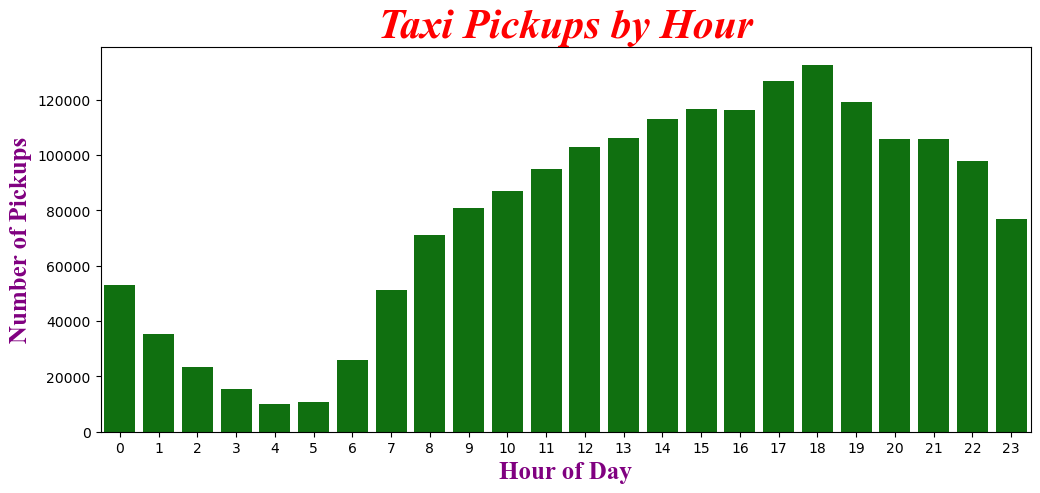

In [166]:
plt.figure(figsize=(12, 5))

sns.barplot(data=hourly_trends,x="pickup_hour",y="pickup_count",color="g")
plt.title("Taxi Pickups by Hour",fontdict={"c":"r","size":30,"fontstyle":"italic","fontweight":"black","fontname":"Times New Roman"})
plt.xlabel("Hour of Day",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.ylabel("Number of Pickups",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.savefig("taxi_pickups_by_hour.jpg", dpi=600)
plt.show()

In [167]:
# Find and show the daily trends in taxi pickups (days of the week)
df.pickup_day_name.value_counts()


pickup_day_name
Thursday     293995
Wednesday    288071
Friday       279584
Saturday     272861
Tuesday      272283
Sunday       237529
Monday       234024
Name: count, dtype: int64

In [168]:
daily_trends = df.pickup_day_name.value_counts().reset_index()
daily_trends.columns = ["pickup_day_name","pickup_count"]
order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]

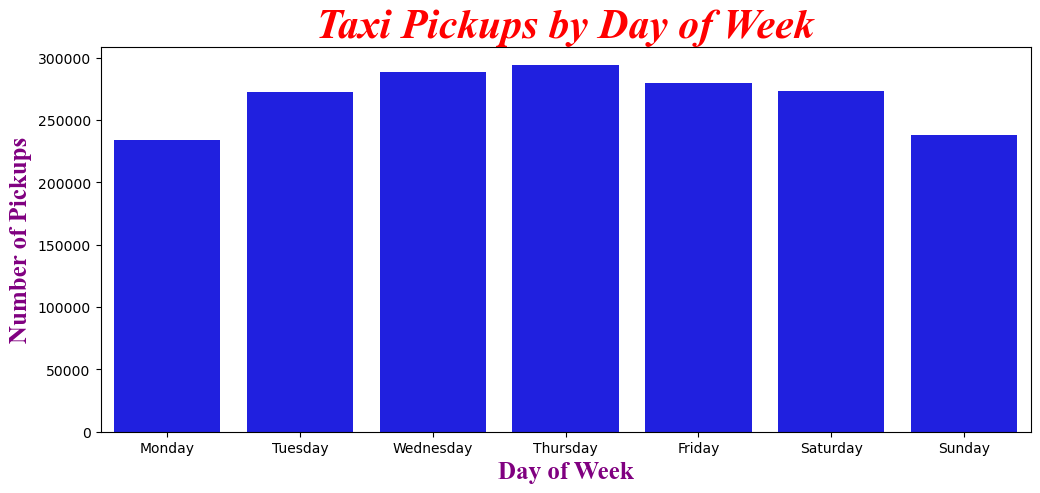

In [169]:
plt.figure(figsize=(12, 5))

sns.barplot(data=daily_trends,x="pickup_day_name",y="pickup_count",order=order,color="blue")

plt.title("Taxi Pickups by Day of Week",fontdict={"c":"r","size":30,"fontstyle":"italic","fontweight":"black","fontname":"Times New Roman"})
plt.xlabel("Day of Week",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.ylabel("Number of Pickups",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.savefig("taxi_pickups_by_day_of_week.jpg", dpi=600)
plt.show()

In [170]:
# Show the monthly trends in pickups
monthly_trends = df.Month_Name.value_counts().reset_index()
monthly_trends.columns = ["Month_Name","pickup_count"]

month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]

In [171]:
monthly_trends

,Month_Name,pickup_count
0,October,172602
1,May,172492
2,March,167138
3,December,164974
4,November,163459
5,June,162291
6,April,161468
7,January,150676
8,February,143156
9,July,142367


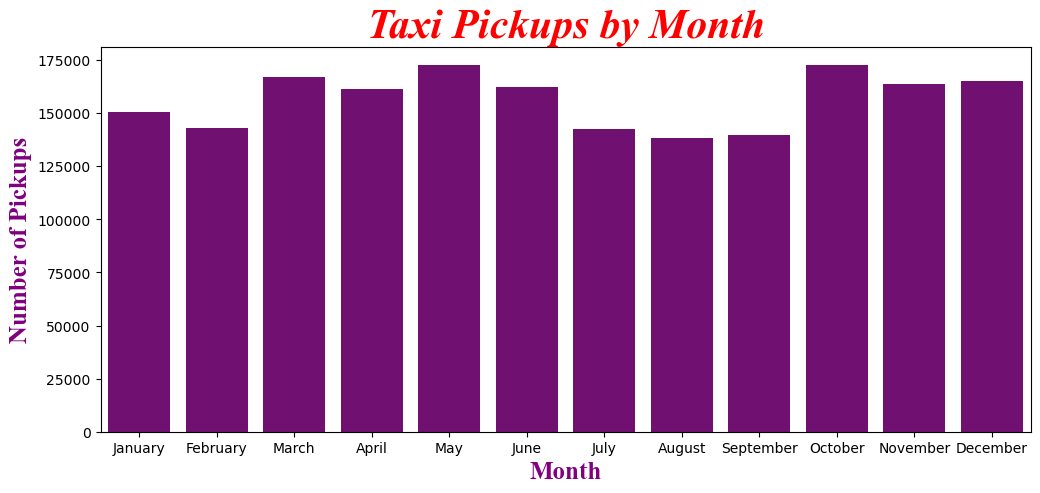

In [172]:
plt.figure(figsize=(12, 5))

sns.barplot(data=monthly_trends,x="Month_Name",y="pickup_count",order=month_order,color="purple")

plt.title("Taxi Pickups by Month",fontdict={"c":"r","size":30,"fontstyle":"italic","fontweight":"black","fontname":"Times New Roman"})
plt.xlabel("Month",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.ylabel("Number of Pickups",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.savefig("taxi_pickups_by_month.jpg", dpi=600)
plt.show()

----

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

## This was previously Done We have handelled all the Negative and Zero values and handelled them.
- Although tip_amount column still have some 0 vals its because tip was not recieved at those records.

In [173]:
df[df.tip_amount==0].shape[0]

422883

In [174]:
# Analyse the above parameters

# All the parameters were analyzed and clearly done above.

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [175]:
# Create a df with non zero entries for the selected parameters.

df[df.trip_distance==0].shape[0]

#Already Handelled.

0

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [176]:
# Group data by month and analyse monthly revenue
monthly_revenue = df.groupby("Month_Name")["total_amount"].sum().reset_index()
monthly_revenue.columns = ["Month_Name", "total_revenue"]
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]

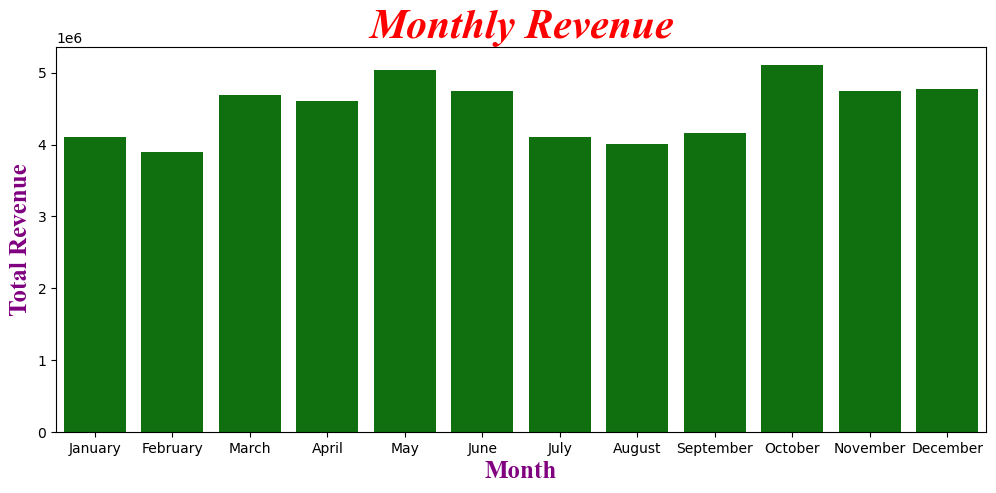

In [177]:
plt.figure(figsize=(12, 5))

sns.barplot(data=monthly_revenue,x="Month_Name",y="total_revenue",order=month_order,color="g")

plt.title("Monthly Revenue",fontdict={"c":"r","size":30,"fontstyle":"italic","fontweight":"black","fontname":"Times New Roman"})
plt.xlabel("Month",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.ylabel("Total Revenue",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.savefig("monthly_revenue.jpg", dpi=600)
plt.show()

In [178]:
print("Highest revenue month:",monthly_revenue.loc[monthly_revenue.total_revenue.idxmax(),"Month_Name"])
print("Highest revenue:",monthly_revenue["total_revenue"].max())
print("Lowest revenue month:",monthly_revenue.loc[monthly_revenue.total_revenue.idxmin(),"Month_Name"])
print("Lowest revenue:",monthly_revenue["total_revenue"].min())

Highest revenue month: October
Highest revenue: 5106615.84
Lowest revenue month: February
Lowest revenue: 3897516.18


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [179]:
# Calculate proportion of each quarter



In [180]:
df["Quarter"] = df["tpep_pickup_datetime"].dt.quarter

In [181]:
quarterly_revenue = df.groupby("Quarter")["total_amount"].sum().reset_index()
quarterly_revenue.columns = ["Quarter", "total_revenue"]
quarterly_revenue

,Quarter,total_revenue
0,1,12703423.59
1,2,14399408.50
2,3,12288002.78
3,4,14623996.41


In [182]:
quarterly_revenue["revenue_proportion"] = (quarterly_revenue.total_revenue / df.total_amount.sum()) * 100
quarterly_revenue

,Quarter,total_revenue,revenue_proportion
0,1,12703423.59,23.518399
1,2,14399408.50,26.658250
2,3,12288002.78,22.749313
3,4,14623996.41,27.074039


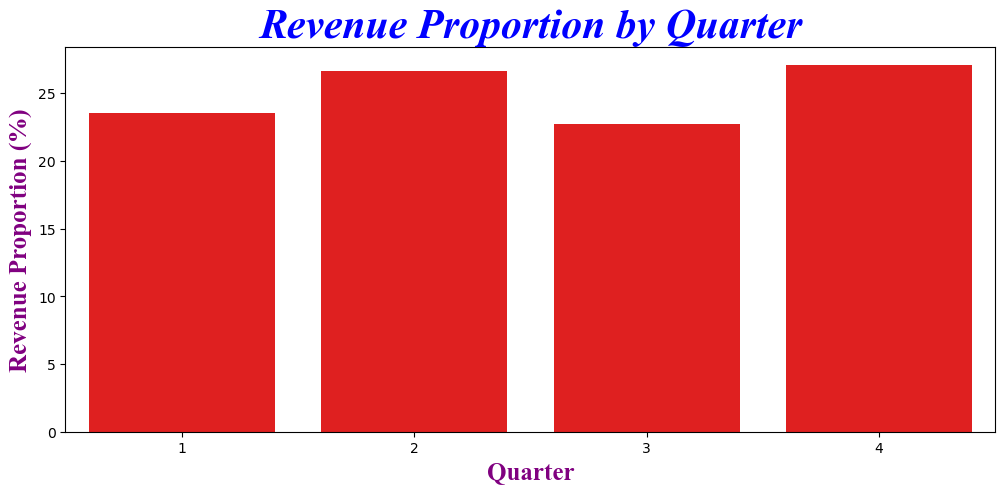

In [183]:
plt.figure(figsize=(12, 5))

sns.barplot(data=quarterly_revenue, x="Quarter", y="revenue_proportion",color="r")

plt.title("Revenue Proportion by Quarter",fontdict={"c":"b","size":30,"fontstyle":"italic","fontweight":"black","fontname":"Times New Roman"})
plt.xlabel("Quarter",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.ylabel("Revenue Proportion (%)",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.savefig("revenue_proportion_by_quarter.jpg", dpi=300)
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

### The data was already handelled for records where trip distance==0.

In [184]:
print("(Correlation betweenn trip_distance and fare_amount): ",df.trip_distance.corr(df.fare_amount))

(Correlation betweenn trip_distance and fare_amount):  0.9547170641703683


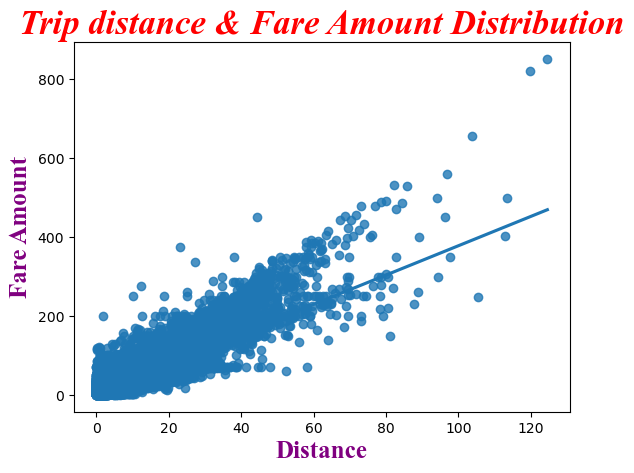

In [185]:
sns.regplot(data=df,x="trip_distance",y="fare_amount")

plt.title("Trip distance & Fare Amount Distribution",fontdict={"c":"r","size":25,"fontstyle":"italic","fontweight":"black","fontname":"Times New Roman"})
plt.xlabel("Distance",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.ylabel("Fare Amount",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.savefig("trip_distance_vs_fare_amount.jpg", dpi=300)
plt.show()

In [186]:
# Show how trip fare is affected by distance



### Analysis: There is a strong positive relationship between trip distance and fare amount. The correlation coefficient is approximately 0.9485, indicating that longer trips generally have higher fares.

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [187]:
# Show relationship between fare and trip duration

print("Correlation between fare_amount and Minutes_Taken:",df.fare_amount.corr(df.Minutes_Taken))

Correlation between fare_amount and Minutes_Taken: 0.8556343252201976


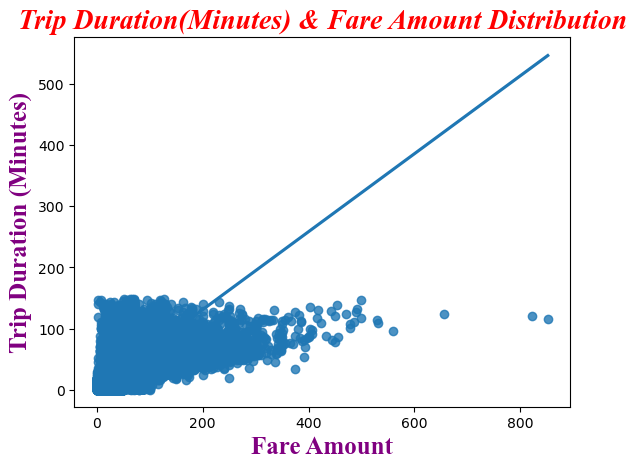

In [188]:
sns.regplot(data=df,x="fare_amount",y="Minutes_Taken")

plt.title("Trip Duration(Minutes) & Fare Amount Distribution",fontdict={"c":"r","size":20,"fontstyle":"italic","fontweight":"black","fontname":"Times New Roman"})
plt.xlabel("Fare Amount",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.ylabel("Trip Duration (Minutes)",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.savefig("trip_duration_vs_fare_amount.jpg", dpi=300)
plt.show()

### There is a strong positive relationship between fare amount and trip duration. This means that fares tend to increase as trip duration increases.

---

In [189]:
# Show relationship between fare and number of passengers

print("Correlation between fare_amount and Number of Passenger:",df.fare_amount.corr(df.passenger_count))

Correlation between fare_amount and Number of Passenger: 0.03891011102168961


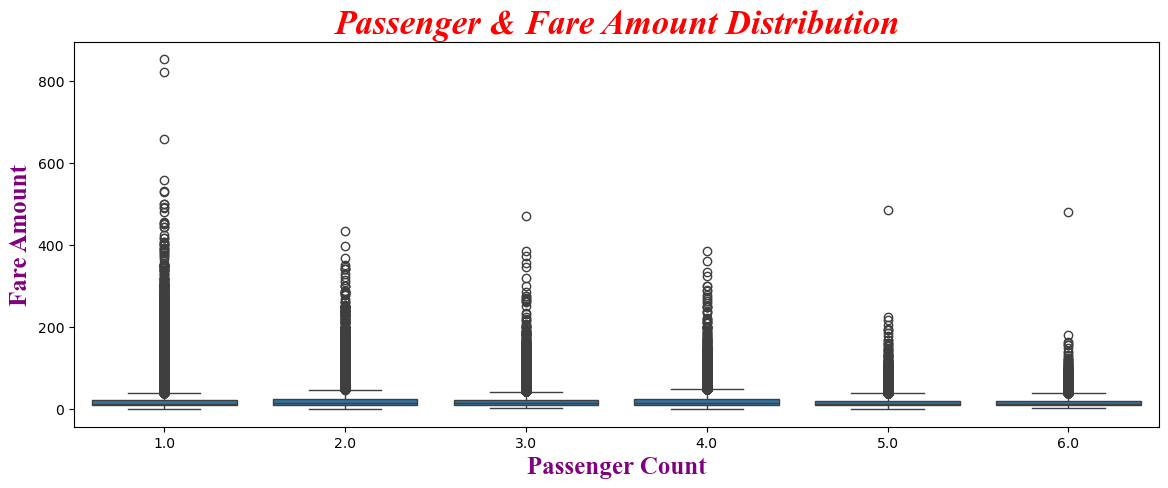

In [190]:
plt.figure(figsize=(14,5))
sns.boxplot(data=df,x="passenger_count",y="fare_amount")

plt.title("Passenger & Fare Amount Distribution",fontdict={"c":"r","size":25,"fontstyle":"italic","fontweight":"black","fontname":"Times New Roman"})
plt.xlabel("Passenger Count",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.ylabel("Fare Amount",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.savefig("passenger_count_vs_fare_amount.jpg", dpi=300)
plt.show()

### There is almost no relationship between fare amount and passenger count. This suggests that the number of passengers has very little effect on the fare amount.

---

In [191]:
# Show relationship between tip and trip distance

print("Correlation between tip and Number of trip distance:",df.tip_amount.corr(df.trip_distance))

Correlation between tip and Number of trip distance: 0.5969947594653958


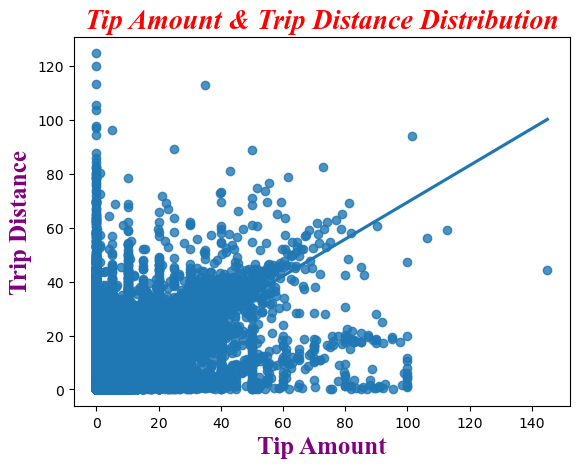

In [192]:
sns.regplot(data=df,x="tip_amount",y="trip_distance")

plt.title("Tip Amount & Trip Distance Distribution",fontdict={"c":"r","size":20,"fontstyle":"italic","fontweight":"black","fontname":"Times New Roman"})
plt.xlabel("Tip Amount",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.ylabel("Trip Distance",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.savefig("tip_amount_vs_trip_distance.jpg", dpi=300)
plt.show()

### There is a moderate positive relationship between tip amount and trip distance. This means that longer trips generally tend to have higher tip amounts.

## Among the three relationships, tip amount and trip distance have the strongest correlation, while fare amount and passenger count have almost no correlation.

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [193]:
# Analyse the distribution of different payment types (payment_type).




- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



In [194]:
payment_counts = df["payment_type"].value_counts().sort_index()
payment_counts.index = payment_counts.index.map({1: "Credit Card",2: "Cash",3: "No Charge",4: "Dispute",0:"Flex Fare Trip"})

payment_counts

payment_type
Flex Fare Trip      64104
Credit Card       1484317
Cash               310027
No Charge            7342
Dispute             12557
Name: count, dtype: int64

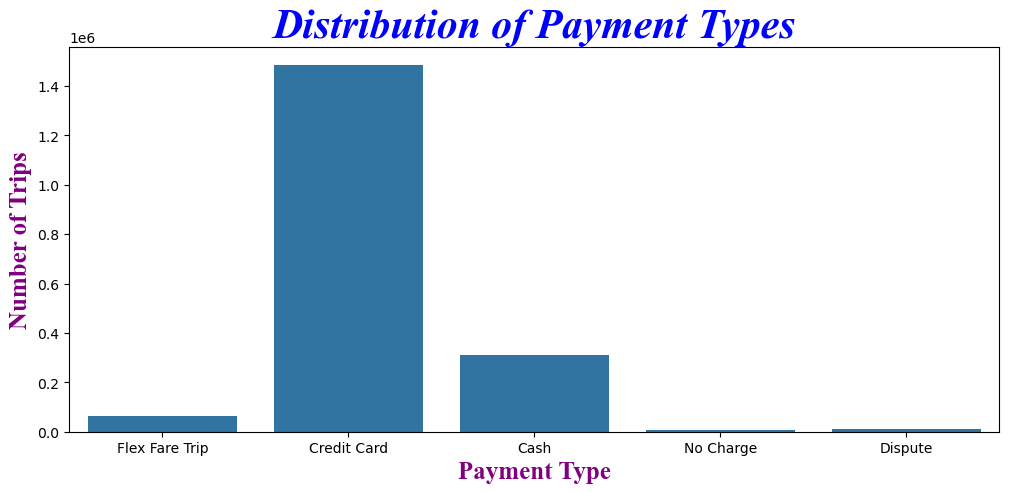

In [195]:
plt.figure(figsize=(12,5))
sns.barplot(x=payment_counts.index, y=payment_counts.values)

plt.title("Distribution of Payment Types",fontdict={"c":"b","size":30,"fontstyle":"italic","fontweight":"black","fontname":"Times New Roman"})
plt.xlabel("Payment Type",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.ylabel("Number of Trips",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.savefig("payment_types_distribution.jpg", dpi=300)
plt.show()

### Credit Card is the most commonly used payment method, followed by Cash. Flex Fare is used less, while No Charge and Dispute are very low.

#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [196]:
# Find routes which have the slowest speeds at different times of the day



In [197]:
route_time = df.groupby(["PULocationID", "DOLocationID", "pickup_hour"]).agg(avg_speed=("speed_mph", "mean"),avg_duration=("Minutes_Taken", "mean"),trip_count=("pickup_hour", "count")).reset_index()

route_time[route_time.trip_count >= 5].sort_values("avg_speed").head(10)

,PULocationID,DOLocationID,pickup_hour,avg_speed,avg_duration,trip_count
96189,207,207,9,1.222797,1.270000,10
96190,207,207,10,1.727929,1.417857,28
96188,207,207,8,2.036363,1.283333,12
96192,207,207,12,2.099675,1.245833,24
96193,207,207,13,2.440476,0.757143,7
96191,207,207,11,2.890559,1.168750,16
92744,186,100,13,3.657180,11.856322,87
92742,186,100,11,3.771543,12.595890,73
93446,186,164,12,3.937150,12.193243,74
98741,211,211,21,3.961406,11.070000,10


### Slow routes we found (like 186→100) show cabs get stuck there a lot — good to know for planning better routes.

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [198]:
# Visualise the number of trips per hour and find the busiest hour



In [199]:
hourly_trends = df.pickup_hour.value_counts().reset_index(name="pickup_count").sort_values("pickup_hour")
hourly_trends

,pickup_hour,pickup_count
16,0,53047
18,1,35332
20,2,23510
21,3,15467
23,4,10187
22,5,10892
19,6,26019
17,7,51209
15,8,70895
13,9,80897


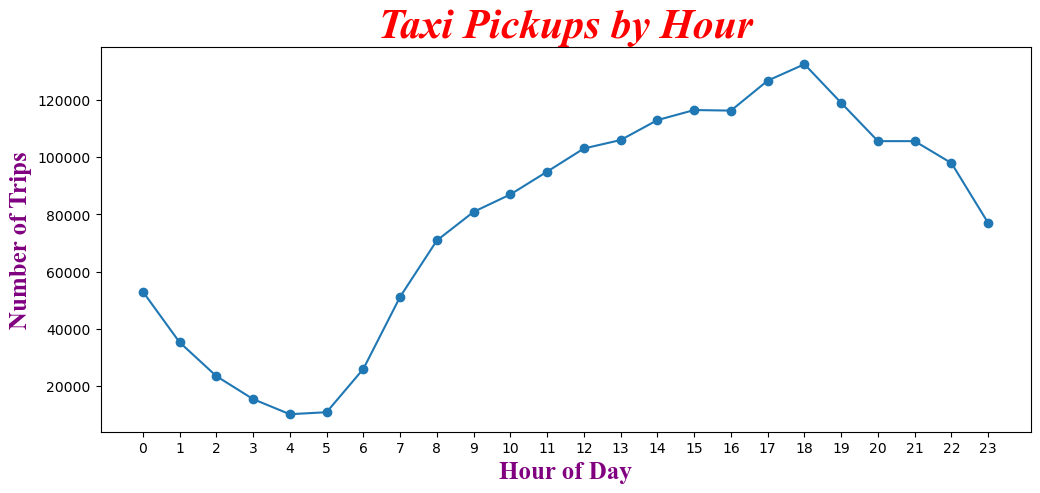

In [200]:
plt.figure(figsize=(12, 5))

plt.plot(hourly_trends.pickup_hour.astype(str),hourly_trends.pickup_count,marker="o")
plt.title("Taxi Pickups by Hour",fontdict={"c":"r","size":30,"fontstyle":"italic","fontweight":"black","fontname":"Times New Roman"})
plt.xlabel("Hour of Day",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.ylabel("Number of Trips",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.savefig("taxi_pickups_by_hour.jpg", dpi=600)
plt.show()

In [201]:
print("Busiest Hour & Number of Pickups:")
hourly_trends.loc[hourly_trends.pickup_count.idxmax(), ["pickup_hour", "pickup_count"]].to_frame()

Busiest Hour & Number of Pickups:


,0
pickup_hour,18
pickup_count,132475


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [202]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers



In [203]:
hourly_trends.sort_values("pickup_count",ascending=False).head(5)

,pickup_hour,pickup_count
0,18,132475
1,17,126743
2,19,118955
3,15,116467
4,16,116270


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [204]:
# Compare traffic trends for the week days and weekends



In [205]:
df["day_type"] = np.where(df.pickup_day_name.isin(["Saturday","Sunday"]),"Weekends","Weekdays")

In [206]:
hourly_day_type = df.groupby(["pickup_hour", "day_type"]).size().reset_index(name="trip_count")
hourly_day_type

,pickup_hour,day_type,trip_count
0,0,Weekdays,26260
1,0,Weekends,26787
2,1,Weekdays,13121
3,1,Weekends,22211
4,2,Weekdays,7364
5,2,Weekends,16146
6,3,Weekdays,4519
7,3,Weekends,10948
8,4,Weekdays,4494
9,4,Weekends,5693


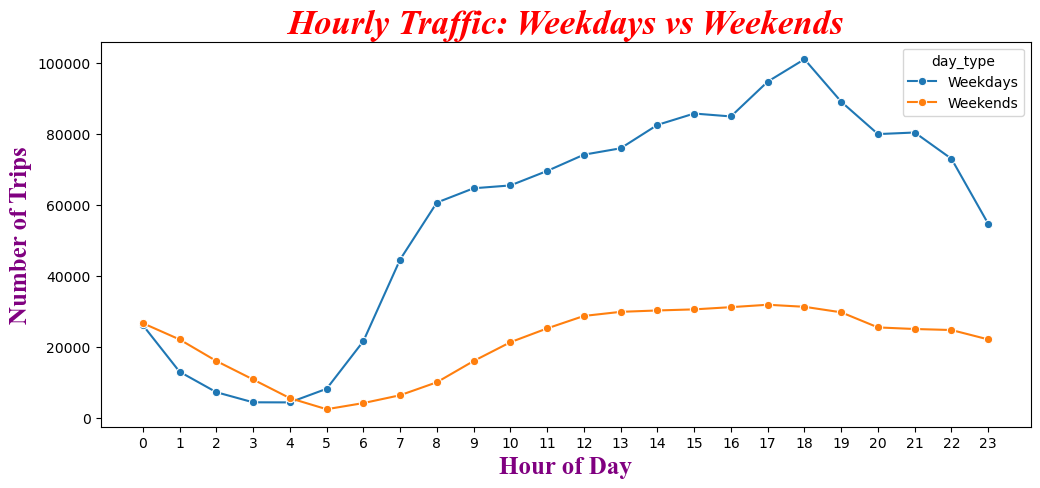

In [207]:
plt.figure(figsize=(12,5))

sns.lineplot(data=hourly_day_type,x="pickup_hour",y="trip_count",hue="day_type",marker="o")

plt.title("Hourly Traffic: Weekdays vs Weekends",fontdict={"c":"r","size":25,"fontstyle":"italic","fontweight":"black","fontname":"Times New Roman"})
plt.xlabel("Hour of Day",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.ylabel("Number of Trips",fontdict={"c":"purple","size":18,"fontstyle":"normal","fontweight":"black","fontname":"Times New Roman"})
plt.xticks(range(24))
plt.savefig("hourly_traffic_weekdays_vs_weekends.jpg", dpi=600)
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

#### Weekdays are busier during the day and evening. Weekends have a different traffic pattern. Finding busy and quiet hours helps manage drivers better and reduce waiting time.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [208]:
# Find top 10 pickup and dropoff zones



In [209]:
top_pickup = df.PULocationID.value_counts().head(10).reset_index()
top_pickup.columns = ["pickup_id","pickup_count"]
top_pickup


,pickup_id,pickup_count
0,132,95203
1,237,88428
2,161,86960
3,236,79481
4,162,66557
5,186,64458
6,138,63911
7,230,62623
8,142,62154
9,170,55426


In [210]:
pickup_trends = df[df["PULocationID"].isin(top_pickup.pickup_id.values)].groupby(["pickup_hour", "PULocationID"]).size().reset_index(name="trip_count").sort_values("trip_count",ascending=False)
pickup_trends

,pickup_hour,PULocationID,trip_count
183,18,161,7592
173,17,161,7221
189,18,237,6781
220,22,132,6771
179,17,237,6704
...,...,...,...
28,2,236,68
38,3,236,44
51,5,138,26
31,3,138,20


In [211]:
top_10_pickup = pickup_trends.loc[pickup_trends.groupby("PULocationID")["trip_count"].idxmax()].sort_values("trip_count", ascending=False).head(10)

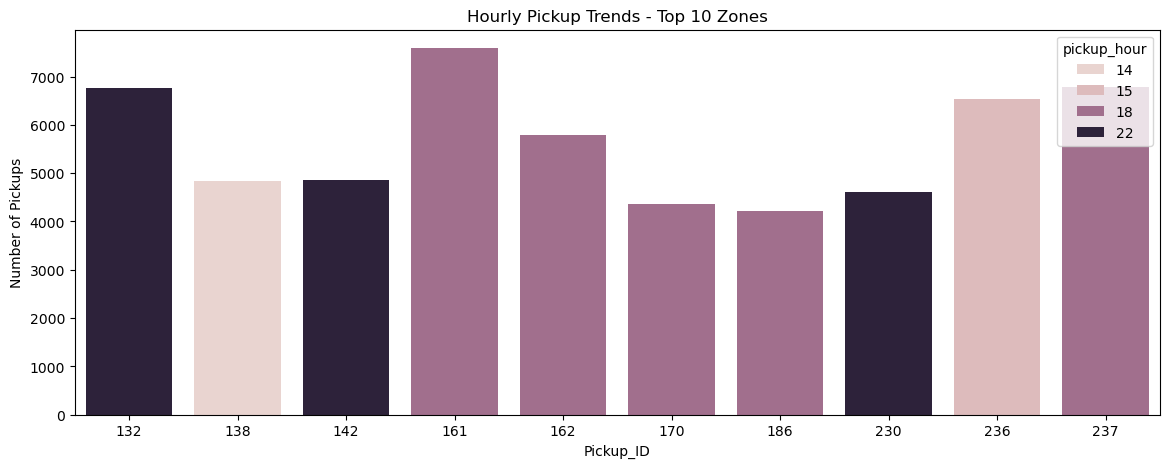

In [212]:
plt.figure(figsize=(14,5))
sns.barplot(data=top_10_pickup, x="PULocationID", y="trip_count",hue="pickup_hour",)
plt.title("Hourly Pickup Trends - Top 10 Zones")
plt.xlabel("Pickup_ID")
plt.ylabel("Number of Pickups")
plt.savefig("hourly_pickup_trends_top_10_zones.png", dpi=300)
plt.show()

In [213]:
top_dropoff = df.DOLocationID.value_counts().head(10).reset_index()
top_dropoff.columns = ["dropoff_id","pickup_count"]
top_dropoff

,dropoff_id,pickup_count
0,236,83100
1,237,79554
2,161,72881
3,230,58075
4,170,55440
5,162,52966
6,239,52645
7,142,52632
8,141,49749
9,68,47496


In [214]:
pickup_trends_drop = df[df["DOLocationID"].isin(top_dropoff.dropoff_id.values)].groupby(["pickup_hour", "DOLocationID"]).size().reset_index(name="trip_count").sort_values("trip_count",ascending=False)
pickup_trends_drop

,pickup_hour,DOLocationID,trip_count
157,15,236,6350
188,18,237,6201
128,12,237,6171
187,18,236,6128
178,17,237,6026
...,...,...,...
43,4,161,114
49,4,239,110
47,4,236,102
48,4,237,89


In [215]:
top_10_dropoff = pickup_trends_drop.loc[pickup_trends_drop.groupby("DOLocationID")["trip_count"].idxmax()].sort_values("trip_count", ascending=False).head(10)

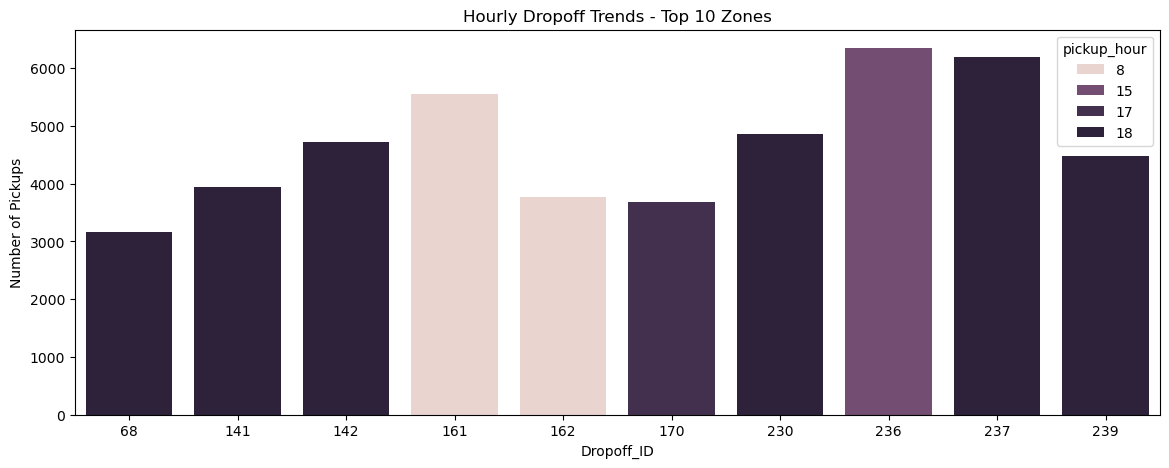

In [216]:
plt.figure(figsize=(14,5))
sns.barplot(data=top_10_dropoff, x="DOLocationID", y="trip_count",hue="pickup_hour",)
plt.title("Hourly Dropoff Trends - Top 10 Zones")
plt.xlabel("Dropoff_ID")
plt.ylabel("Number of Pickups")
plt.savefig("hourly_dropoff_trends_top_10_zones.png", dpi=300)
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [217]:
# Find the top 10 and bottom 10 pickup/dropoff ratios



In [218]:
zones = pd.DataFrame({"pickups": df.PULocationID.value_counts(),"dropoffs": df.DOLocationID.value_counts()})
zones

,pickups,dropoffs
1,57.0,5669
2,6.0,5
3,36.0,165
4,2326.0,7264
5,17.0,22
...,...,...
261,9515.0,9205
262,25301.0,28870
263,35907.0,38717
264,17010.0,17482


In [219]:
zones["ratio"] = zones.pickups/zones.dropoffs

In [220]:
zones

,pickups,dropoffs,ratio
1,57.0,5669,0.010055
2,6.0,5,1.200000
3,36.0,165,0.218182
4,2326.0,7264,0.320209
5,17.0,22,0.772727
...,...,...,...
261,9515.0,9205,1.033677
262,25301.0,28870,0.876377
263,35907.0,38717,0.927422
264,17010.0,17482,0.973001


In [221]:
zones.sort_values("ratio", ascending=False).head(10)   # highest

,pickups,dropoffs,ratio
70,8434.0,1002,8.417166
132,95203.0,20913,4.552336
138,63911.0,24074,2.654773
186,64458.0,41224,1.563604
114,25124.0,18102,1.387913
43,31273.0,22905,1.365335
249,41638.0,31148,1.336779
162,66557.0,52966,1.256599
2,6.0,5,1.200000
100,31003.0,25979,1.193387


In [222]:
zones.sort_values("ratio", ascending=True).head(10)   #lowest

,pickups,dropoffs,ratio
1,57.0,5669,0.010055
58,1.0,50,0.020000
6,1.0,40,0.025000
118,1.0,35,0.028571
245,1.0,32,0.031250
240,2.0,61,0.032787
46,2.0,59,0.033898
206,2.0,44,0.045455
96,3.0,64,0.046875
115,1.0,20,0.050000


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [223]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones



In [224]:
night_df = df[~((df.pickup_hour>5) & (df.pickup_hour<23))]

In [225]:
night_df.PULocationID.value_counts().head(10)

PULocationID
79     16477
132    14512
249    12844
48     10563
148    10438
114     9087
230     8437
186     7159
164     6414
68      6324
Name: count, dtype: int64

In [226]:
night_df.DOLocationID.value_counts().head(10)

DOLocationID
79     8732
48     7211
170    6405
68     6004
107    5947
141    5587
263    5456
249    5019
230    4881
148    4503
Name: count, dtype: int64

In [227]:
night_pickup = night_df.PULocationID.value_counts().head(10).reset_index()
night_pickup.columns = ["PULocationID", "pickup_count"]
night_pickup

,PULocationID,pickup_count
0,79,16477
1,132,14512
2,249,12844
3,48,10563
4,148,10438
5,114,9087
6,230,8437
7,186,7159
8,164,6414
9,68,6324


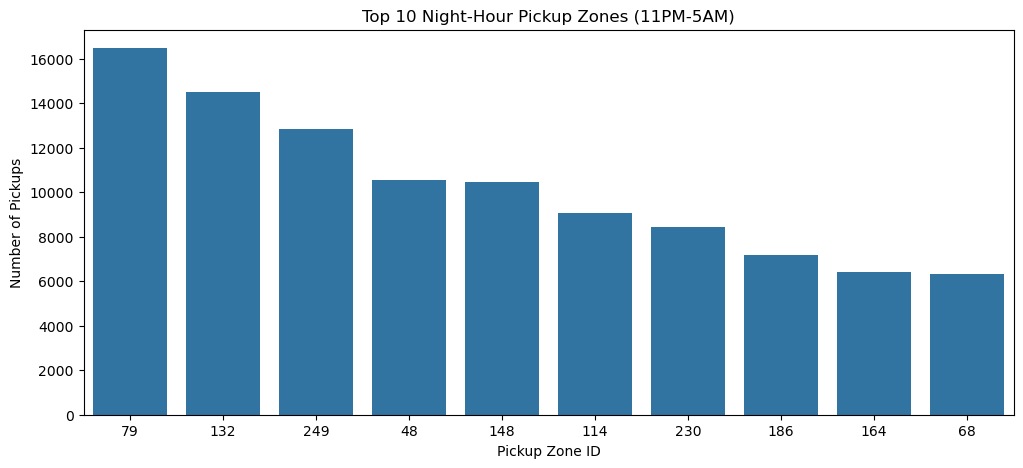

In [228]:
plt.figure(figsize=(12, 5))
sns.barplot(data=night_pickup, x="PULocationID", y="pickup_count", order=night_pickup.PULocationID.astype(str))
plt.title("Top 10 Night-Hour Pickup Zones (11PM-5AM)")
plt.xlabel("Pickup Zone ID")
plt.ylabel("Number of Pickups")
plt.savefig("top_10_night_hour_pickup_zones.png", dpi=600)
plt.show()

In [229]:
night_drop = night_df.DOLocationID.value_counts().head(10).reset_index()
night_drop.columns = ["DOLocationID", "pickup_count"]
night_drop

,DOLocationID,pickup_count
0,79,8732
1,48,7211
2,170,6405
3,68,6004
4,107,5947
5,141,5587
6,263,5456
7,249,5019
8,230,4881
9,148,4503


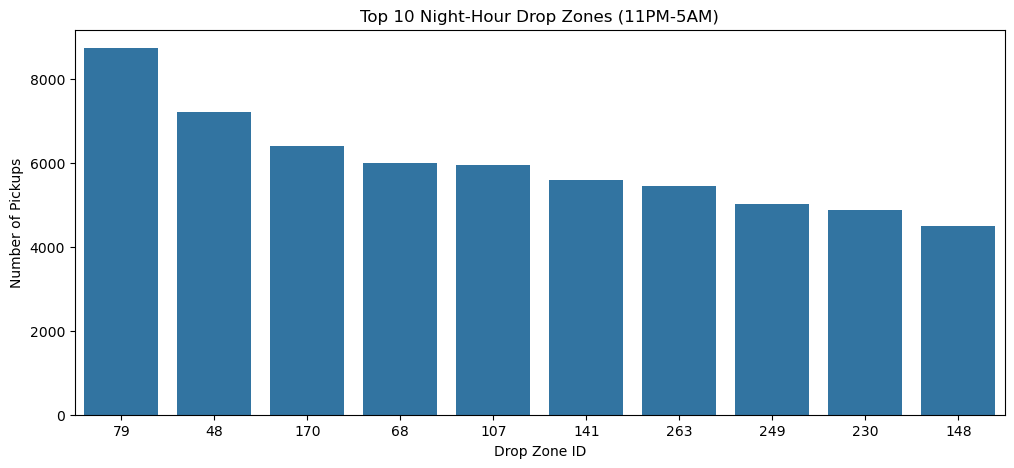

In [230]:
plt.figure(figsize=(12, 5))
sns.barplot(data=night_drop, x="DOLocationID", y="pickup_count", order=night_drop.DOLocationID.astype(str))
plt.title("Top 10 Night-Hour Drop Zones (11PM-5AM)")
plt.xlabel("Drop Zone ID")
plt.ylabel("Number of Pickups")
plt.savefig("top_10_night_hour_drop_zones.png", dpi=600)
plt.show()

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [231]:
# Filter for night hours (11 PM to 5 AM)



In [232]:
night_hours = [23,0,1,2,3,4,5]

In [233]:
night_revenue = df[df.pickup_hour.isin(night_hours)].total_amount.sum()
day_revenue = df[~df.pickup_hour.isin(night_hours)].total_amount.sum()

In [234]:
night_revenue,day_revenue

(np.float64(6590211.68), np.float64(47424619.6))

In [235]:
labels = ["Daytime", "Nighttime"]

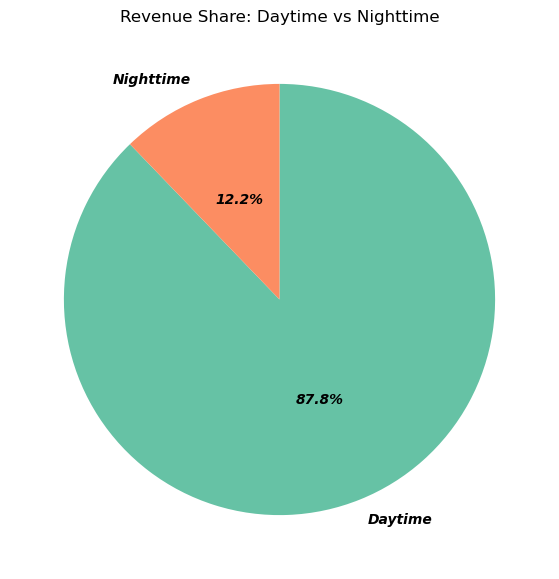

In [236]:
plt.figure(figsize=(14, 7))

plt.pie(x=[day_revenue,night_revenue],labels=labels,autopct="%1.1f%%",colors=sns.color_palette("Set2"),pctdistance=0.5,labeldistance=1.1,startangle=90,counterclock=False,
       textprops={"color":"black","fontweight":"black","fontstyle":"italic"})

plt.title("Revenue Share: Daytime vs Nighttime")
plt.savefig("revenue_share_daytime_vs_nighttime.png", dpi=600)
plt.show()

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [237]:
# Analyse the fare per mile per passenger for different passenger counts




In [238]:
df["fare_per_mile"] = df.fare_amount/df.trip_distance

In [239]:
fare_per_mile_per_passenger = (df.fare_per_mile / df.passenger_count).groupby(df.passenger_count).mean()

fare_per_mile_per_passenger

passenger_count
1.0    8.386469
2.0    4.047680
3.0    2.893902
4.0    2.325197
5.0    1.606183
6.0    1.340019
dtype: float64

**3.2.10** <font color = red>[5 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [240]:
# Compare the average fare per mile for different days and for different times of the day



In [241]:
hourly_fare_per_mile = df.groupby("pickup_hour")["fare_per_mile"].mean().reset_index()

hourly_fare_per_mile

,pickup_hour,fare_per_mile
0,0,7.275097
1,1,7.428734
2,2,7.493030
3,3,7.830433
4,4,7.595632
5,5,7.530202
6,6,6.705982
7,7,7.315282
8,8,8.034609
9,9,8.401589


In [242]:
hourly_fare_per_mile.pickup_hour = hourly_fare_per_mile.pickup_hour.astype(str)

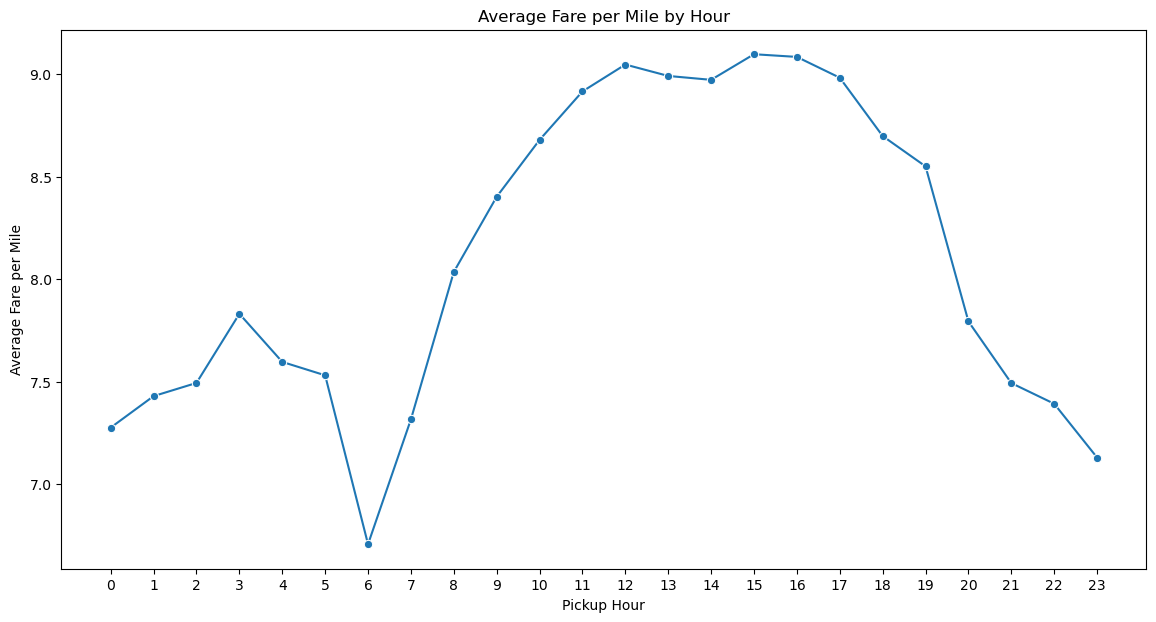

In [243]:
plt.figure(figsize=(14,7))
sns.lineplot(data=hourly_fare_per_mile,x="pickup_hour",y="fare_per_mile",marker="o")

plt.xlabel("Pickup Hour")
plt.ylabel("Average Fare per Mile")
plt.title("Average Fare per Mile by Hour")
plt.savefig("average_fare_per_mile_by_hour.png", dpi=300)
plt.show()

In [244]:
df["pickup_day"] = df.tpep_pickup_datetime.dt.day_name()

In [245]:
daily_fare_per_mile = df.groupby("pickup_day")["fare_per_mile"].mean().reset_index()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
daily_fare_per_mile

,pickup_day,fare_per_mile
0,Friday,8.441290
1,Monday,7.967314
2,Saturday,8.319610
3,Sunday,7.685441
4,Thursday,8.643033
5,Tuesday,8.596991
6,Wednesday,8.718077


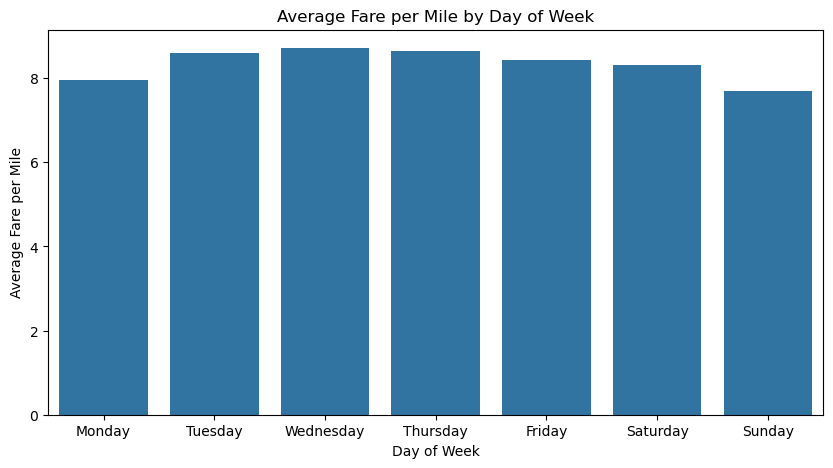

In [246]:
plt.figure(figsize=(10,5))

sns.barplot(data=daily_fare_per_mile,x="pickup_day",y="fare_per_mile",order=order)

plt.xlabel("Day of Week")
plt.ylabel("Average Fare per Mile")
plt.title("Average Fare per Mile by Day of Week")
plt.savefig("average_fare_per_mile_by_day.png", dpi=600)
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [247]:
# Compare fare per mile for different vendors



In [248]:
hourly_vendor_fare = (df.groupby(["pickup_hour", "VendorID"])["fare_per_mile"].mean().reset_index())

hourly_vendor_fare

,pickup_hour,VendorID,fare_per_mile
0,0,1,6.832837
1,0,2,7.411388
2,0,6,3.444484
3,1,1,6.915217
4,1,2,7.586038
...,...,...,...
65,22,2,7.505409
66,22,6,3.986885
67,23,1,6.821788
68,23,2,7.224288


In [249]:
hourly_vendor_fare["VendorID"] = hourly_vendor_fare["VendorID"].replace({1: "Creative Mobile Technologies, LLC",2: "Curb Mobility, LLC",6: "Myle Technologies Inc"})

hourly_vendor_fare

,pickup_hour,VendorID,fare_per_mile
0,0,"Creative Mobile Technologies, LLC",6.832837
1,0,"Curb Mobility, LLC",7.411388
2,0,Myle Technologies Inc,3.444484
3,1,"Creative Mobile Technologies, LLC",6.915217
4,1,"Curb Mobility, LLC",7.586038
...,...,...,...
65,22,"Curb Mobility, LLC",7.505409
66,22,Myle Technologies Inc,3.986885
67,23,"Creative Mobile Technologies, LLC",6.821788
68,23,"Curb Mobility, LLC",7.224288


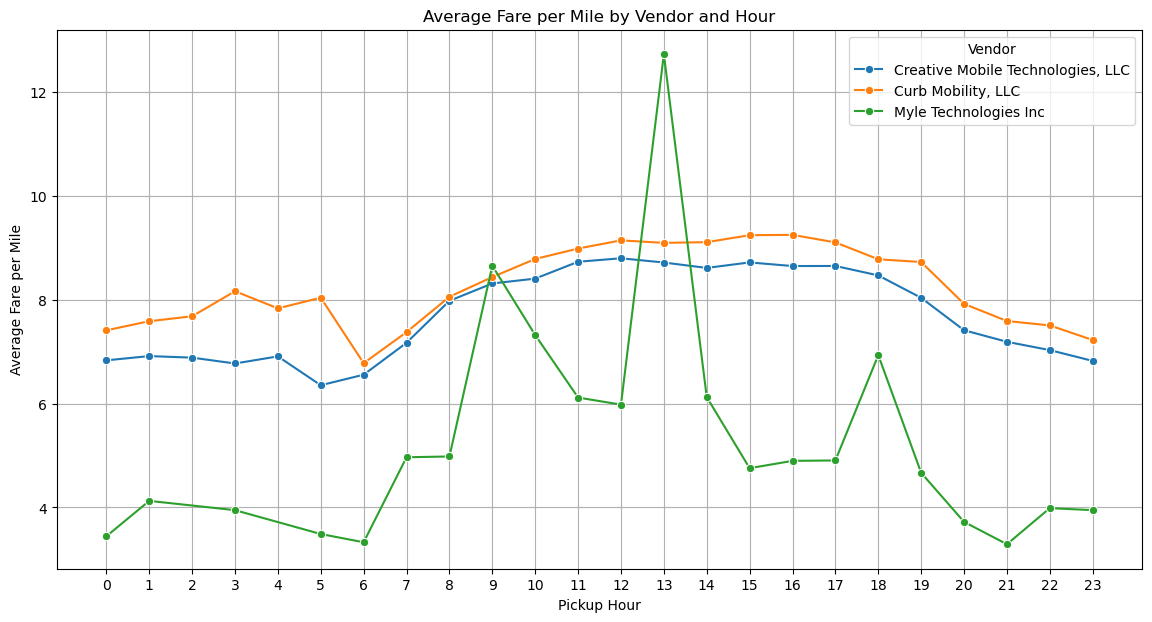

In [250]:
plt.figure(figsize=(14,7))

sns.lineplot(data=hourly_vendor_fare,x="pickup_hour",y="fare_per_mile",hue="VendorID",marker="o")

plt.xlabel("Pickup Hour")
plt.ylabel("Average Fare per Mile")
plt.title("Average Fare per Mile by Vendor and Hour")
plt.xticks(range(24))
plt.legend(title="Vendor")
plt.grid(True)
plt.savefig("average_fare_per_mile_by_vendor_hour.png", dpi=300)
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [251]:
# Defining distance tiers



In [252]:
df["distance_tier"] = np.where(df.trip_distance <= 2,"Up to 2 miles",np.where(df.trip_distance <= 5,"2 to 5 miles","More than 5 miles"))

In [253]:
df.distance_tier.value_counts()

distance_tier
Up to 2 miles        1031997
2 to 5 miles          516246
More than 5 miles     330104
Name: count, dtype: int64

In [254]:
tier_vendor_fare = df.groupby(["distance_tier", "VendorID"])["fare_per_mile"].mean().reset_index()

tier_vendor_fare

,distance_tier,VendorID,fare_per_mile
0,2 to 5 miles,1,6.422290
1,2 to 5 miles,2,6.540429
2,2 to 5 miles,6,8.696840
3,More than 5 miles,1,4.424962
4,More than 5 miles,2,4.487948
5,More than 5 miles,6,4.249279
6,Up to 2 miles,1,9.821067
7,Up to 2 miles,2,10.814682
8,Up to 2 miles,6,32.243158


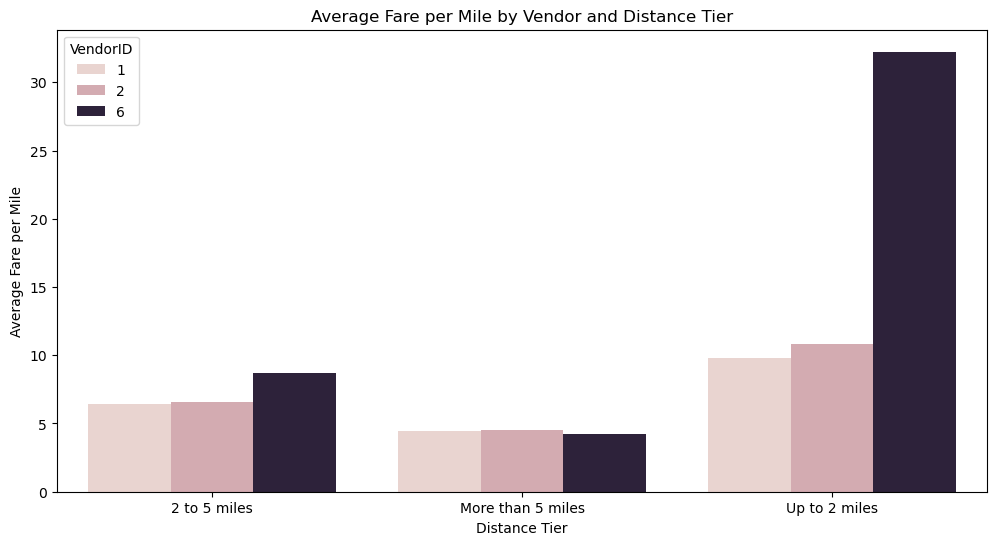

In [255]:
plt.figure(figsize=(12,6))

sns.barplot(data=tier_vendor_fare,x="distance_tier",y="fare_per_mile",hue="VendorID")

plt.xlabel("Distance Tier")
plt.ylabel("Average Fare per Mile")
plt.title("Average Fare per Mile by Vendor and Distance Tier")
plt.savefig("average_fare_per_mile_by_vendor_distance.png", dpi=300)
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [256]:
#  Analyze tip percentages based on distances, passenger counts and pickup times



In [257]:
df["tip_percentage"] = (df.tip_amount/df.fare_amount) * 100

In [258]:
avg_tip_distance = df.groupby("distance_tier")["tip_percentage"].mean().reset_index()

avg_tip_distance

,distance_tier,tip_percentage
0,2 to 5 miles,18.405017
1,More than 5 miles,16.342216
2,Up to 2 miles,22.658941


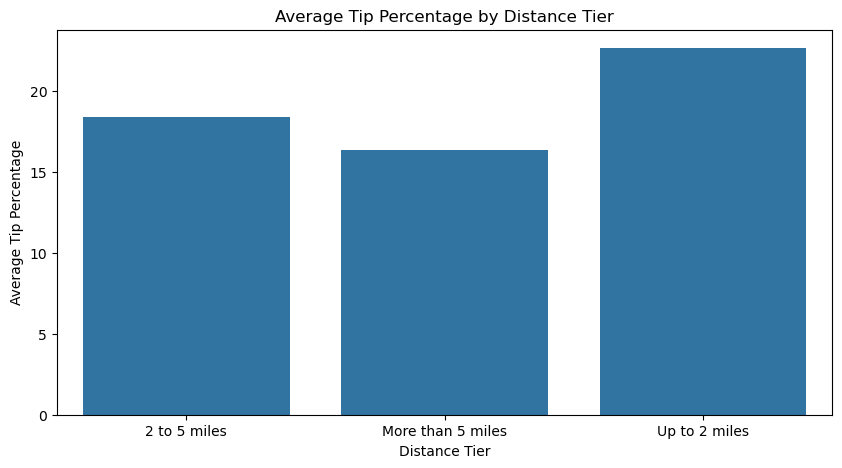

In [259]:
plt.figure(figsize=(10,5))

sns.barplot(data=avg_tip_distance,x="distance_tier",y="tip_percentage")

plt.xlabel("Distance Tier")
plt.ylabel("Average Tip Percentage")
plt.title("Average Tip Percentage by Distance Tier")
plt.savefig("average_tip_percentage_by_trip_distance.png", dpi=300)
plt.show()

In [260]:
avg_tip_passenger = df.groupby("passenger_count")["tip_percentage"].mean().reset_index()

avg_tip_passenger

,passenger_count,tip_percentage
0,1.0,20.569331
1,2.0,20.023285
2,3.0,19.248039
3,4.0,17.378031
4,5.0,20.674759
5,6.0,20.644071


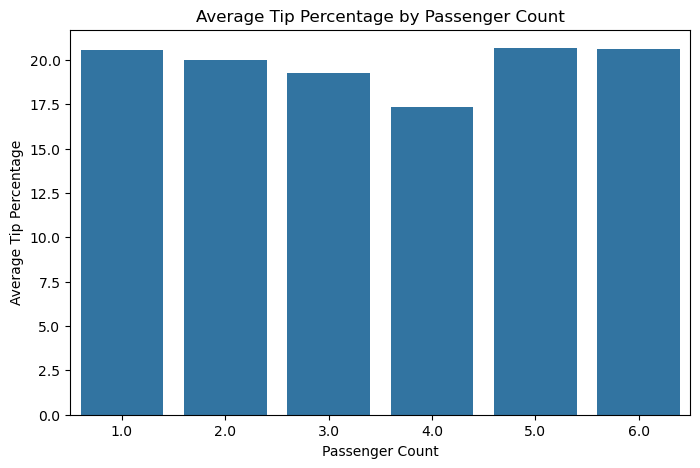

In [261]:
plt.figure(figsize=(8,5))

sns.barplot(data=avg_tip_passenger, x="passenger_count", y="tip_percentage")

plt.xlabel("Passenger Count")
plt.ylabel("Average Tip Percentage")
plt.title("Average Tip Percentage by Passenger Count")
plt.savefig("average_tip_percentage_by_passenger_count.png", dpi=300)
plt.show()

In [262]:
avg_tip_hour = df.groupby("pickup_hour")["tip_percentage"].mean().reset_index()

avg_tip_hour

,pickup_hour,tip_percentage
0,0,23.784663
1,1,20.268445
2,2,19.916044
3,3,19.576246
4,4,17.187767
5,5,17.100106
6,6,17.897248
7,7,22.226919
8,8,19.794042
9,9,19.558211


In [263]:
avg_tip_hour.pickup_hour = avg_tip_hour.pickup_hour.astype(str)

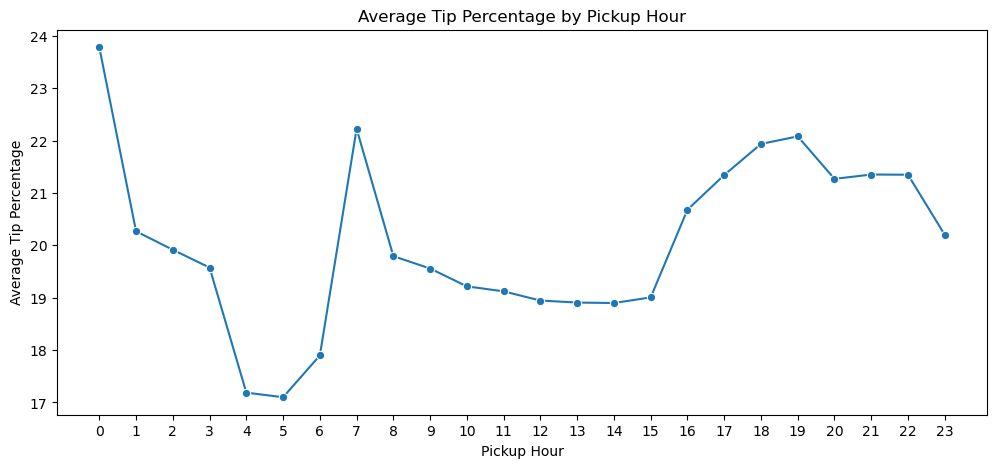

In [264]:
plt.figure(figsize=(12,5))

sns.lineplot(data=avg_tip_hour, x="pickup_hour", y="tip_percentage",marker="o")

plt.xlabel("Pickup Hour")

plt.ylabel("Average Tip Percentage")
plt.title("Average Tip Percentage by Pickup Hour")
plt.savefig("average_tip_percentage_by_pickup_hour.png", dpi=300)
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [265]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



In [266]:
low_tip = df[df.tip_percentage < 10]
high_tip = df[df.tip_percentage > 25]

In [267]:
comparison = pd.DataFrame({"Low Tip (<10%)": low_tip[["trip_distance", "passenger_count", "pickup_hour"]].mean(),"High Tip (>25%)": high_tip[["trip_distance", "passenger_count", "pickup_hour"]].mean()})

comparison

,Low Tip (<10%),High Tip (>25%)
trip_distance,3.904545,2.311716
passenger_count,1.401198,1.359017
pickup_hour,13.906865,14.591312


**3.2.14** <font color = red>[5 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [268]:
# See how passenger count varies across hours and days



In [269]:
avg_passenger = df.groupby(["pickup_hour", "pickup_day_name"])["passenger_count"].mean().reset_index()

avg_passenger

,pickup_hour,pickup_day_name,passenger_count
0,0,Friday,1.339986
1,0,Monday,1.394763
2,0,Saturday,1.440947
3,0,Sunday,1.469592
4,0,Thursday,1.329334
...,...,...,...
163,23,Saturday,1.485873
164,23,Sunday,1.402541
165,23,Thursday,1.360766
166,23,Tuesday,1.343504


In [271]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday","Friday", "Saturday", "Sunday"]
passenger_pivot = avg_passenger.pivot(index="pickup_day_name",columns="pickup_hour",values="passenger_count").reindex(day_order)
passenger_pivot

pickup_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
pickup_day_name,,,,,,,,,,,,,,,,,,,,,,,,
Monday,1.394763,1.366852,1.372389,1.398417,1.351831,1.241314,1.248244,1.252290,1.280309,1.292316,1.333959,1.343625,1.352731,1.364098,1.377531,1.377290,1.378060,1.360108,1.347862,1.351265,1.358787,1.375803,1.373664,1.384156
Tuesday,1.381557,1.384135,1.362500,1.381783,1.314788,1.217528,1.224142,1.246846,1.258732,1.264805,1.301294,1.309845,1.318693,1.330133,1.344780,1.352135,1.340546,1.313086,1.316310,1.313295,1.339787,1.350882,1.363585,1.343504
Wednesday,1.377994,1.370938,1.366460,1.380741,1.333768,1.229579,1.229636,1.243882,1.256151,1.254083,1.311933,1.316677,1.325069,1.331915,1.334075,1.352627,1.349312,1.332465,1.309526,1.321089,1.337126,1.354170,1.353476,1.353764
Thursday,1.329334,1.353663,1.370298,1.349257,1.347299,1.282299,1.220087,1.247627,1.250964,1.263120,1.296994,1.330600,1.317818,1.339806,1.349920,1.358827,1.351347,1.340831,1.331881,1.335476,1.360053,1.385405,1.374283,1.360766
Friday,1.339986,1.371317,1.388357,1.375307,1.287217,1.237908,1.213699,1.262376,1.286543,1.310357,1.338247,1.344407,1.359779,1.369701,1.375170,1.388196,1.394242,1.392665,1.388205,1.412970,1.447278,1.466967,1.472593,1.464445
Saturday,1.440947,1.434022,1.444725,1.424498,1.387135,1.284519,1.256153,1.310426,1.326519,1.390601,1.409359,1.451213,1.452534,1.458312,1.479365,1.486258,1.475426,1.492793,1.467711,1.492034,1.499751,1.500106,1.502899,1.485873
Sunday,1.469592,1.441465,1.448305,1.439455,1.392583,1.303558,1.321615,1.362113,1.376439,1.422240,1.433861,1.443673,1.463480,1.481242,1.487238,1.467725,1.470036,1.464784,1.446344,1.455243,1.444724,1.442719,1.392955,1.402541


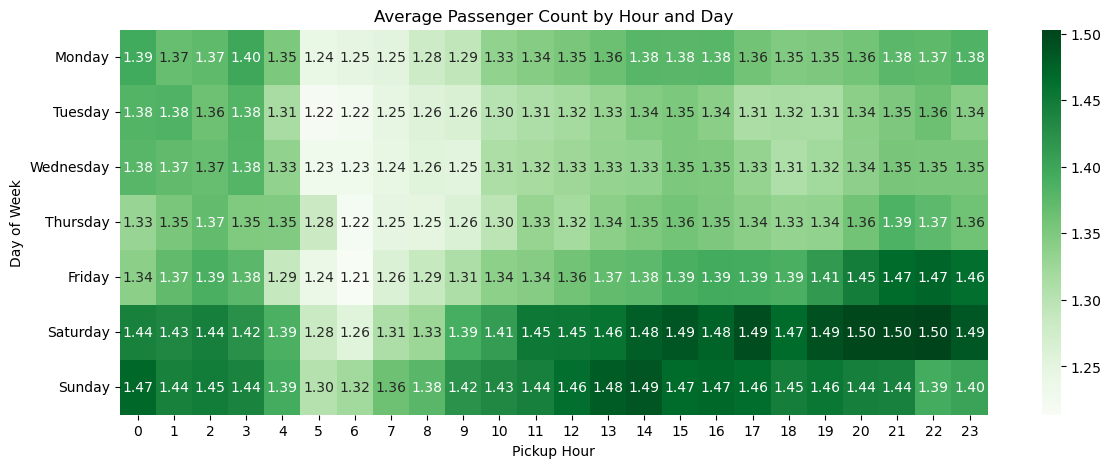

In [272]:
plt.figure(figsize=(14,5))

sns.heatmap(passenger_pivot, annot=True, fmt=".2f",cmap="Greens")

plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week")
plt.title("Average Passenger Count by Hour and Day")
plt.savefig("average_passenger_count_by_hour_and_day.png", dpi=600)
plt.show()

### Dropping Store_and_fwd_flag as this is of no use in our analysis

In [273]:
df.drop(columns=["store_and_fwd_flag"], inplace=True)

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

- Avoid the known slow routes (186→100, 186→164, zone 207 same-zone trips) during their worst hours (11am–1pm) — reroute cabs around them if possible.
- Position more cabs around high-demand zones such as 161, 132, 236 and 237 before the 6 PM peak, rather than waiting until demand has already reached its highest point.
- Handle night-time dispatching separately. During 11 PM–5 AM, Zone 79 is the strongest common pickup and dropoff hub, followed by other active zones such as 132, 249 and 48. Maintaining taxi availability around these areas can better match the late-night demand pattern.
- Reduce unnecessary taxi movement during low-demand periods, particularly around the early morning when trip activity is lowest. This can help avoid having too many taxis travelling or waiting when demand is relatively low.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

- Position more cabs in the major demand zones, especially Zones 161, 132, 236 and 237, which show high pickup/dropoff activity.
- Increase cab availability before the evening peak, particularly around 6 PM, when overall taxi demand is highest. The analysis shows about 132,475 trips at 6 PM, while demand is much lower around 4–5 AM.
- Use different positioning strategies for weekdays and weekends. Weekdays have much stronger daytime demand and a clear 6 PM peak, while weekend demand is lower and more spread out, with relatively stronger activity during late-night/early-morning hours.
- For late-night operations (11 PM–5 AM), shift some cabs toward high nighttime-demand zones, particularly Zone 79, followed by Zones 132 and 249.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

### Use targeted pricing instead of increasing fares everywhere. Routes that are slower because of congestion, such as 186→100 and 186→164, take more time during 11 AM–1 PM. A small fare adjustment during these specific periods could help compensate for the extra time and operating inefficiency.

### Also monitor the price gap between vendors on short trips. Vendor 2 has a higher average fare per mile than Vendor 1, especially for trips under 2 miles. If this difference becomes too large, Vendor 2 could become less attractive for short-distance customers. Pricing should therefore remain competitive on short trips while allowing higher fares where longer trips or slower routes justify them.